# 01: Structural Analysis

Data: master_dataset, wits_exports_by_hs2
Period: 2007-2021 (WITS), 1960-2024 (master)
N: 65 obs (master), 15 yr (gravity)

In [ ]:
# ============================================================
# ANALYSE DÉPENDANCE RUSSIE-CHINE
# Axes 1 & 2 : Mesure de Dépendance + Ruptures Structurelles
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuration plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Chemins robustes (notebook dans notebooks/ ou a la racine)
_candidates = [Path.cwd(), Path.cwd().parent]
for c in _candidates:
    _proj = c / "russia_china_dependency"
    if _proj.exists() and (_proj / "02_processed_data").exists():
        PROJECT_ROOT = c
        break
else:
    PROJECT_ROOT = Path.cwd()

PROJECT = PROJECT_ROOT / "russia_china_dependency"
DATA_DIR = PROJECT / "02_processed_data"
FIGURES = PROJECT_ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

print("Setup OK")

Setup OK


In [ ]:
# Load master
master = pd.read_csv(DATA_DIR / "master_dataset.csv")

# Load WITS HS2
wits_hs2 = pd.read_csv(DATA_DIR / "wits_exports_by_hs2.csv")

print(f"master: {len(master)} obs, {len(master.columns)} vars")
print(f"Period: {int(master.Year.min())} - {int(master.Year.max())}")
print(f"\nVariables disponibles:")
for i, col in enumerate(master.columns, 1):
    print(f"  {i:2d}. {col}")

master: 65 obs, 35 vars
Period: 1960 - 2024

Variables disponibles:
   1. Year
   2. Trade_RUS_Exp_to_CHN
   3. Trade_CHN_Exp_to_RUS
   4. CHN_GDP_current_USD
   5. RUS_GDP_current_USD
   6. CHN_GDP_growth_annual_percent
   7. RUS_GDP_growth_annual_percent
   8. CHN_Inflation_consumer_prices_percent
   9. RUS_Inflation_consumer_prices_percent
  10. Diplomatic_Agreement_Score
  11. Oil_Cons_CHN_EJ
  12. Oil_Cons_RUS_EJ
  13. RUS_Export_Dependency_to_CHN_pct
  14. CHN_Export_Dependency_to_RUS_pct
  15. MUV_Index
  16. Energy_Index_Nominal
  17. Metals_Index_Nominal
  18. ToT_Russia_Approx
  19. Crude oil, average
  20. Crude oil, Brent
  21. Coal, Australian
  22. Natural gas, Europe
  23. Aluminum
  24. Copper
  25. Iron ore, cfr spot
  26. Nickel
  27. Gold
  28. HHI_RUS_Exports_to_CHN
  29. ECR_Top1
  30. ECR_Top3
  31. ECR_Top5
  32. WITS_RUS_Exports_to_CHN
  33. WITS_RUS_Imports_from_CHN
  34. Trade_Balance_RUS_CHN
  35. Trade_Balance_Ratio


In [34]:
# Variables clés pour l'analyse
key_vars = [
    "Year",
    "HHI_RUS_Exports_to_CHN",
    "ECR_Top1",
    "ECR_Top3",
    "WITS_RUS_Exports_to_CHN",
    "Trade_Balance_RUS_CHN",
    "ToT_Russia_Approx",
    "Diplomatic_Agreement_Score",
]

# Filtrer années avec données WITS (2007-2021)
analysis_period = master[master["Year"].between(2007, 2021)][key_vars].copy()
analysis_period = analysis_period.set_index("Year")

print("=== DONNÉES CLÉS (2007-2021) ===\n")
display(analysis_period.round(3))

=== DONNÉES CLÉS (2007-2021) ===



,HHI_RUS_Exports_to_CHN,ECR_Top1,ECR_Top3,WITS_RUS_Exports_to_CHN,Trade_Balance_RUS_CHN,ToT_Russia_Approx,Diplomatic_Agreement_Score
Year,,,,,,,
2007,0.240,39.234,78.808,67.485,25.048,104.654,0.879
2008,0.289,46.935,80.714,94.312,33.527,115.054,0.915
2009,0.257,42.617,78.367,70.551,27.466,77.732,0.893
2010,0.267,45.122,77.177,91.056,21.773,100.000,0.855
2011,0.348,54.455,81.590,167.015,79.998,113.946,0.911
2012,0.386,58.021,84.178,171.639,79.327,107.888,0.843
2013,0.405,59.603,86.410,168.969,73.713,105.071,0.844
2014,0.437,62.305,89.392,178.183,85.416,98.067,0.816
2015,0.382,57.333,86.173,131.878,66.855,67.880,0.833


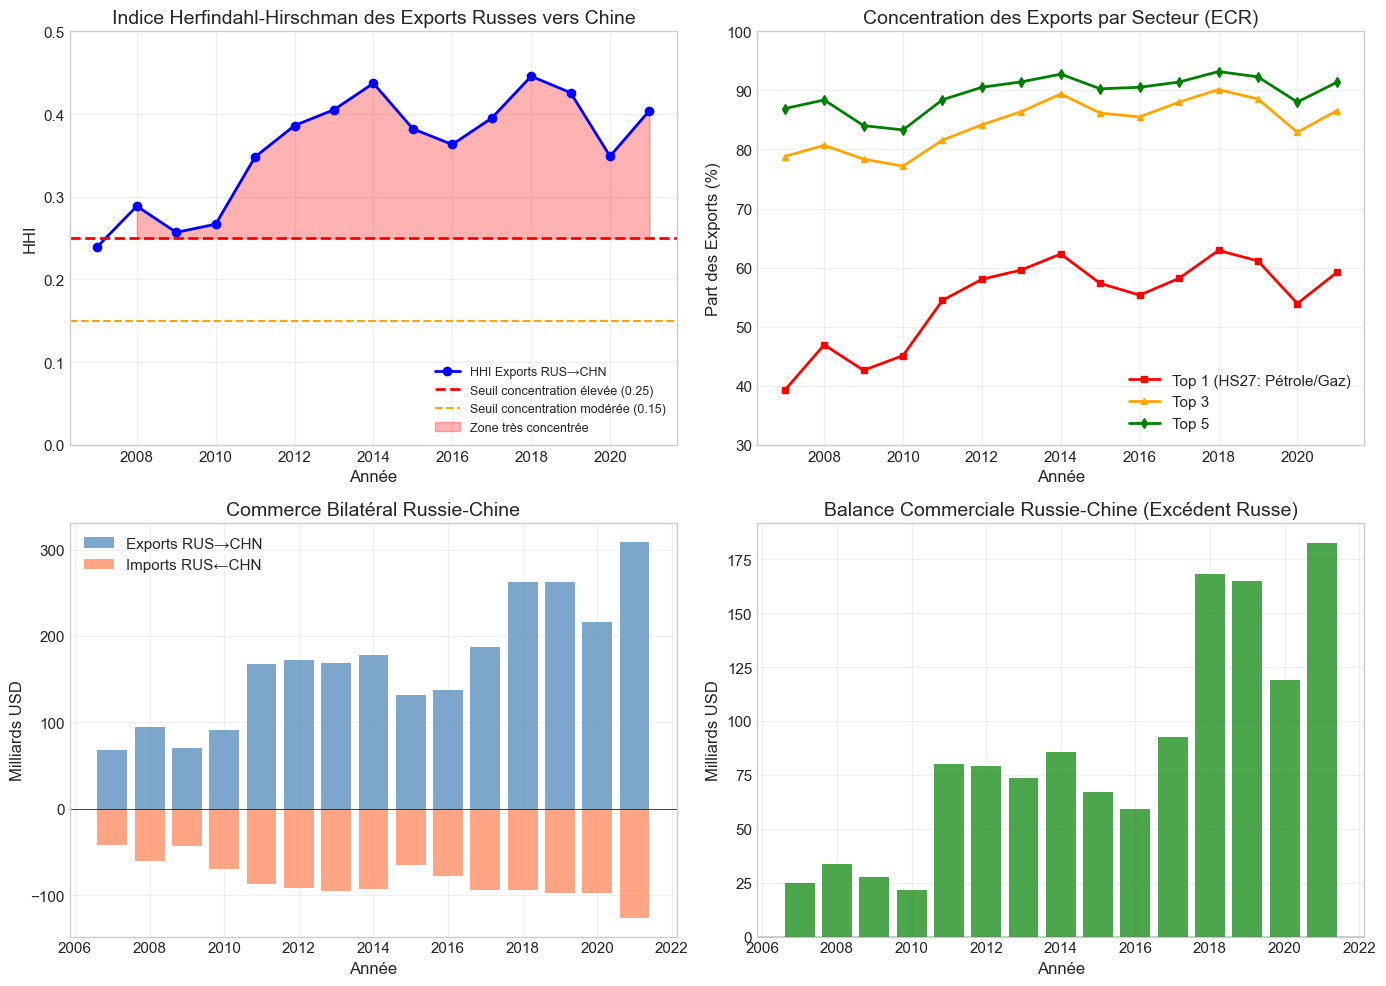


Saved: axe1_dependance_structurelle.png


In [35]:
# ============================================================
# AXE 1 : MESURE DE LA DÉPENDANCE STRUCTURELLE
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- 1. HHI dans le temps ---
ax1 = axes[0, 0]
hhi_data = master[master["HHI_RUS_Exports_to_CHN"].notna()]
ax1.plot(
    hhi_data["Year"],
    hhi_data["HHI_RUS_Exports_to_CHN"],
    "b-o",
    linewidth=2,
    markersize=6,
    label="HHI Exports RUS→CHN",
)
ax1.axhline(
    y=0.25,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Seuil concentration élevée (0.25)",
)
ax1.axhline(
    y=0.15,
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label="Seuil concentration modérée (0.15)",
)
ax1.fill_between(
    hhi_data["Year"],
    0.25,
    hhi_data["HHI_RUS_Exports_to_CHN"],
    where=hhi_data["HHI_RUS_Exports_to_CHN"] > 0.25,
    alpha=0.3,
    color="red",
    label="Zone très concentrée",
)
ax1.set_xlabel("Année")
ax1.set_ylabel("HHI")
ax1.set_title("Indice Herfindahl-Hirschman des Exports Russes vers Chine")
ax1.legend(loc="lower right", fontsize=9)
ax1.set_ylim(0, 0.5)
ax1.grid(True, alpha=0.3)

# --- 2. ECR (Export Concentration Ratio) ---
ax2 = axes[0, 1]
ecr_data = master[master["ECR_Top1"].notna()]
ax2.plot(
    ecr_data["Year"],
    ecr_data["ECR_Top1"],
    "r-s",
    linewidth=2,
    markersize=5,
    label="Top 1 (HS27: Pétrole/Gaz)",
)
ax2.plot(
    ecr_data["Year"],
    ecr_data["ECR_Top3"],
    "orange",
    linestyle="-",
    marker="^",
    linewidth=2,
    markersize=5,
    label="Top 3",
)
ax2.plot(
    ecr_data["Year"],
    ecr_data["ECR_Top5"],
    "g-d",
    linewidth=2,
    markersize=5,
    label="Top 5",
)
ax2.set_xlabel("Année")
ax2.set_ylabel("Part des Exports (%)")
ax2.set_title("Concentration des Exports par Secteur (ECR)")
ax2.legend(loc="lower right")
ax2.set_ylim(30, 100)
ax2.grid(True, alpha=0.3)

# --- 3. Volume des Exports ---
ax3 = axes[1, 0]
trade_data = master[master["WITS_RUS_Exports_to_CHN"].notna()]
ax3.bar(
    trade_data["Year"],
    trade_data["WITS_RUS_Exports_to_CHN"],
    color="steelblue",
    alpha=0.7,
    label="Exports RUS→CHN",
)
ax3.bar(
    trade_data["Year"],
    -trade_data["WITS_RUS_Imports_from_CHN"],
    color="coral",
    alpha=0.7,
    label="Imports RUS←CHN",
)
ax3.axhline(y=0, color="black", linewidth=0.5)
ax3.set_xlabel("Année")
ax3.set_ylabel("Milliards USD")
ax3.set_title("Commerce Bilatéral Russie-Chine")
ax3.legend()
ax3.grid(True, alpha=0.3)

# --- 4. Balance Commerciale ---
ax4 = axes[1, 1]
balance_data = master[master["Trade_Balance_RUS_CHN"].notna()]
colors = ["green" if x > 0 else "red" for x in balance_data["Trade_Balance_RUS_CHN"]]
ax4.bar(
    balance_data["Year"], balance_data["Trade_Balance_RUS_CHN"], color=colors, alpha=0.7
)
ax4.axhline(y=0, color="black", linewidth=1)
ax4.set_xlabel("Année")
ax4.set_ylabel("Milliards USD")
ax4.set_title("Balance Commerciale Russie-Chine (Excédent Russe)")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("axe1_dependance_structurelle.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: axe1_dependance_structurelle.png")

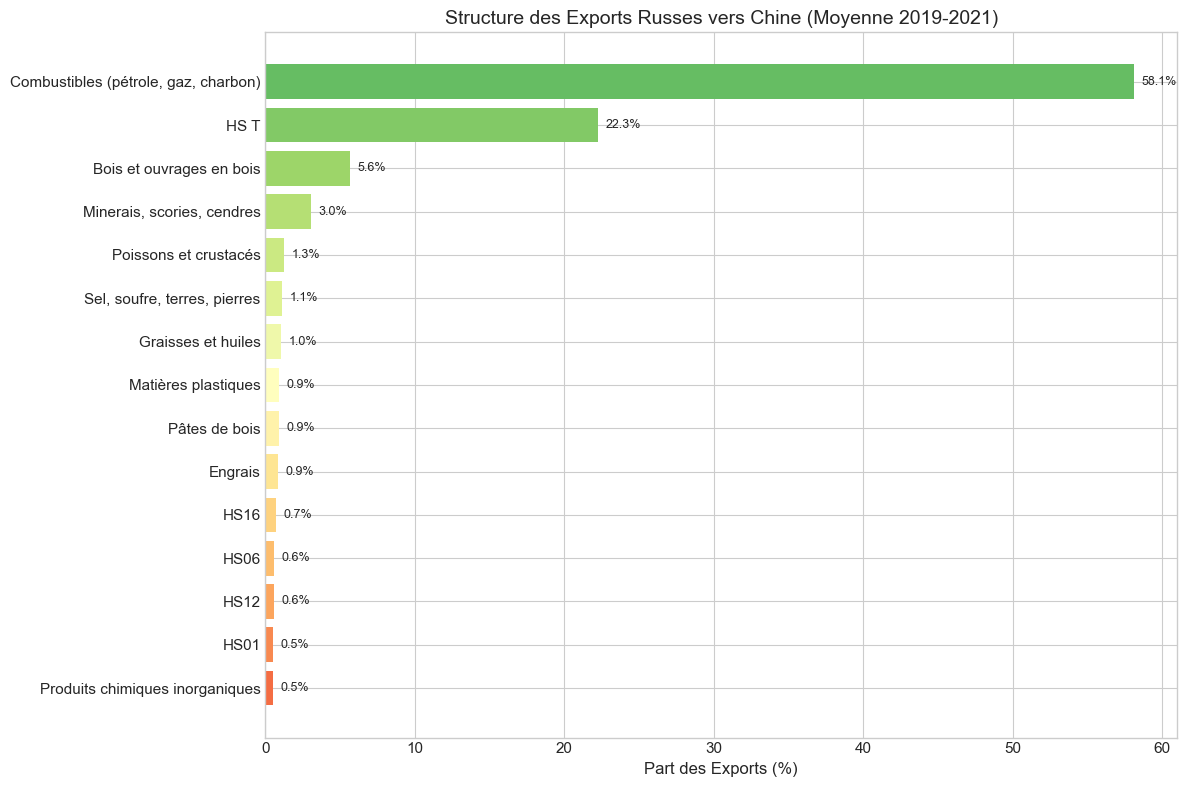


=== TOP SECTEURS EXPORTS RUS→CHN ===

                              Description   Value_Mrd  Share_pct
HS2                                                             
27   Combustibles (pétrole, gaz, charbon)  153.186748  58.078756
 T                                   HS T   58.382294  22.282163
44               Bois et ouvrages en bois   14.644814   5.646642
26             Minerais, scories, cendres    7.974832   3.031651
03                  Poissons et crustacés    3.141783   1.267913
25           Sel, soufre, terres, pierres    2.912606   1.110438
15                     Graisses et huiles    2.627893   1.036305
39                    Matières plastiques    2.407289   0.943790
47                          Pâtes de bois    2.354759   0.905636
31                                Engrais    2.257158   0.852637
16                                   HS16    1.840397   0.698459
06                                   HS06    1.464778   0.575393
12                                   HS12    1.4635

In [36]:
# Top secteurs HS2 (moyenne 2019-2021)
recent_hs2 = (
    wits_hs2[wits_hs2["Year"] >= 2019]
    .groupby("HS2")
    .agg({"Value": "mean", "Share": "mean"})
    .sort_values("Share", ascending=False)
    .head(15)
)

# Descriptions HS2
hs2_descriptions = {
    "27": "Combustibles (pétrole, gaz, charbon)",
    "44": "Bois et ouvrages en bois",
    "26": "Minerais, scories, cendres",
    "03": "Poissons et crustacés",
    "31": "Engrais",
    "28": "Produits chimiques inorganiques",
    "71": "Pierres et métaux précieux",
    "74": "Cuivre et ouvrages",
    "76": "Aluminium et ouvrages",
    "72": "Fonte, fer et acier",
    "47": "Pâtes de bois",
    "25": "Sel, soufre, terres, pierres",
    "15": "Graisses et huiles",
    "39": "Matières plastiques",
    "29": "Produits chimiques organiques",
}

recent_hs2["Description"] = recent_hs2.index.map(
    lambda x: hs2_descriptions.get(x, f"HS{x}")
)
recent_hs2["Value_Mrd"] = recent_hs2["Value"] / 1e6
recent_hs2["Share_pct"] = recent_hs2["Share"] * 100

# Visualisation
fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(recent_hs2)))
bars = ax.barh(recent_hs2["Description"], recent_hs2["Share_pct"], color=colors)
ax.set_xlabel("Part des Exports (%)")
ax.set_title("Structure des Exports Russes vers Chine (Moyenne 2019-2021)")
ax.invert_yaxis()

# Annotations
for bar, val in zip(bars, recent_hs2["Share_pct"]):
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig("axe1_structure_exports.png", dpi=150, bbox_inches="tight")
plt.show()

# Tableau récapitulatif
print("\n=== TOP SECTEURS EXPORTS RUS→CHN ===\n")
print(recent_hs2[["Description", "Value_Mrd", "Share_pct"]].to_string())
print(
    f"\n→ HS27 (Combustibles) représente {recent_hs2.loc['27', 'Share_pct']:.1f}% des exports"
)

=== PONDÉRATIONS ACP (Variance Maximale) ===
  HHI:     0.431 (43.1%)
  ECR:     0.431 (43.1%)
  inv_ToT: 0.138 (13.8%)

  Variance expliquée: 68.2%


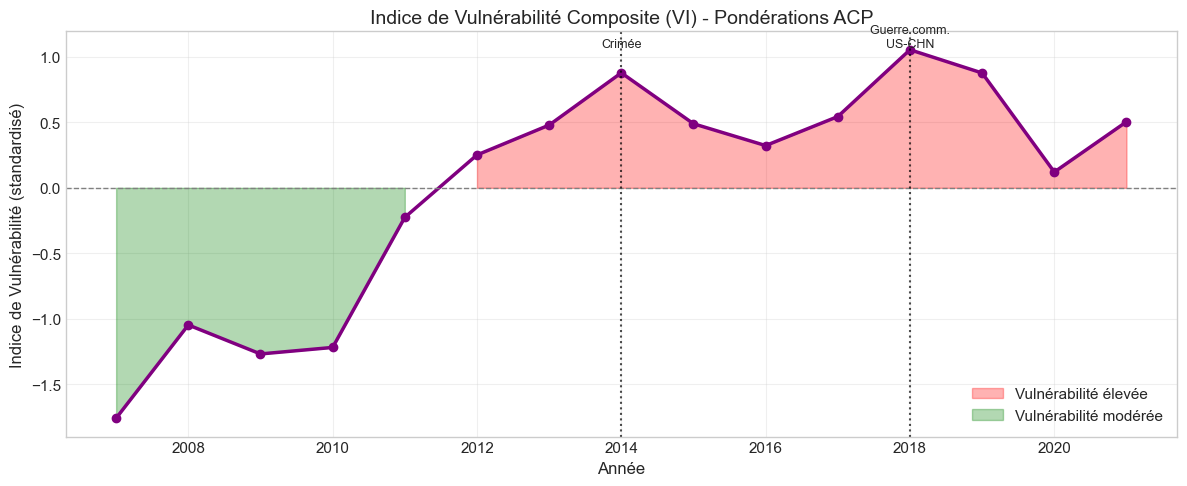

In [37]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Préparation des données pour ACP
vi_data = master[
    ["Year", "HHI_RUS_Exports_to_CHN", "ECR_Top1", "ToT_Russia_Approx"]
].dropna()
vi_data = vi_data.set_index("Year")

# Normaliser ToT pour que valeur haute = vulnérabilité haute
# (ToT bas = défavorable = vulnérable)
vi_data["inv_ToT"] = 100 / vi_data["ToT_Russia_Approx"]

# Variables pour ACP
X = vi_data[["HHI_RUS_Exports_to_CHN", "ECR_Top1", "inv_ToT"]].values

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ACP
pca = PCA(n_components=1)
pca.fit(X_scaled)

# Poids naturels dérivés de l'ACP
weights = np.abs(pca.components_[0])
weights = weights / weights.sum()  # Normaliser à 1

print("=== PONDÉRATIONS ACP (Variance Maximale) ===")
print(f"  HHI:     {weights[0]:.3f} ({weights[0]*100:.1f}%)")
print(f"  ECR:     {weights[1]:.3f} ({weights[1]*100:.1f}%)")
print(f"  inv_ToT: {weights[2]:.3f} ({weights[2]*100:.1f}%)")
print(f"\n  Variance expliquée: {pca.explained_variance_ratio_[0]*100:.1f}%")

# Calcul de l'Indice de Vulnérabilité
vi_data["VI"] = (
    weights[0]
    * (vi_data["HHI_RUS_Exports_to_CHN"] - vi_data["HHI_RUS_Exports_to_CHN"].mean())
    / vi_data["HHI_RUS_Exports_to_CHN"].std()
    + weights[1]
    * (vi_data["ECR_Top1"] - vi_data["ECR_Top1"].mean())
    / vi_data["ECR_Top1"].std()
    + weights[2]
    * (vi_data["inv_ToT"] - vi_data["inv_ToT"].mean())
    / vi_data["inv_ToT"].std()
)

# Visualisation VI
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(vi_data.index, vi_data["VI"], "purple", linewidth=2.5, marker="o", markersize=6)
ax.axhline(y=0, color="gray", linestyle="--", linewidth=1)
ax.fill_between(
    vi_data.index,
    0,
    vi_data["VI"],
    where=vi_data["VI"] > 0,
    alpha=0.3,
    color="red",
    label="Vulnérabilité élevée",
)
ax.fill_between(
    vi_data.index,
    0,
    vi_data["VI"],
    where=vi_data["VI"] < 0,
    alpha=0.3,
    color="green",
    label="Vulnérabilité modérée",
)

# Annotations événements
events = {2014: "Crimée", 2018: "Guerre comm.\nUS-CHN"}
for year, label in events.items():
    if year in vi_data.index:
        ax.axvline(x=year, color="black", linestyle=":", alpha=0.7)
        ax.text(year, ax.get_ylim()[1] * 0.9, label, ha="center", fontsize=9)

ax.set_xlabel("Année")
ax.set_ylabel("Indice de Vulnérabilité (standardisé)")
ax.set_title("Indice de Vulnérabilité Composite (VI) - Pondérations ACP")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("axe1_indice_vulnerabilite.png", dpi=150, bbox_inches="tight")
plt.show()

In [38]:
# ============================================================
# AXE 2 : DÉTECTION DES RUPTURES STRUCTURELLES
# ============================================================

from statsmodels.tsa.stattools import adfuller

# Série à tester
series_hhi = master[master["HHI_RUS_Exports_to_CHN"].notna()].set_index("Year")[
    "HHI_RUS_Exports_to_CHN"
]

# Test ADF
adf_result = adfuller(series_hhi, autolag="AIC")

print("=== TEST DICKEY-FULLER AUGMENTÉ (ADF) ===")
print(f"\nSérie testée: HHI des exports RUS→CHN")
print(f"Observations: {len(series_hhi)}")
print(f"\nRésultats:")
print(f"  ADF Statistic: {adf_result[0]:.4f}")
print(f"  p-value:       {adf_result[1]:.4f}")
print(f"  Lags utilisés: {adf_result[2]}")
print(f"\nValeurs critiques:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value:.4f}")

if adf_result[1] < 0.05:
    print(f"\nOK Série STATIONNAIRE (p < 0.05)")
else:
    print(f"\nNote Série NON STATIONNAIRE (p > 0.05)")
    print("  → Différenciation peut être nécessaire pour certains tests")

=== TEST DICKEY-FULLER AUGMENTÉ (ADF) ===

Série testée: HHI des exports RUS→CHN
Observations: 15

Résultats:
  ADF Statistic: -1.5978
  p-value:       0.4847
  Lags utilisés: 1

Valeurs critiques:
  1%: -4.0689
  5%: -3.1271
  10%: -2.7017

Note Série NON STATIONNAIRE (p > 0.05)
  → Différenciation peut être nécessaire pour certains tests


=== DÉTECTION RUPTURES STRUCTURELLES (Bai-Perron/PELT) ===

Ruptures détectées: 1
  1. Année 2011


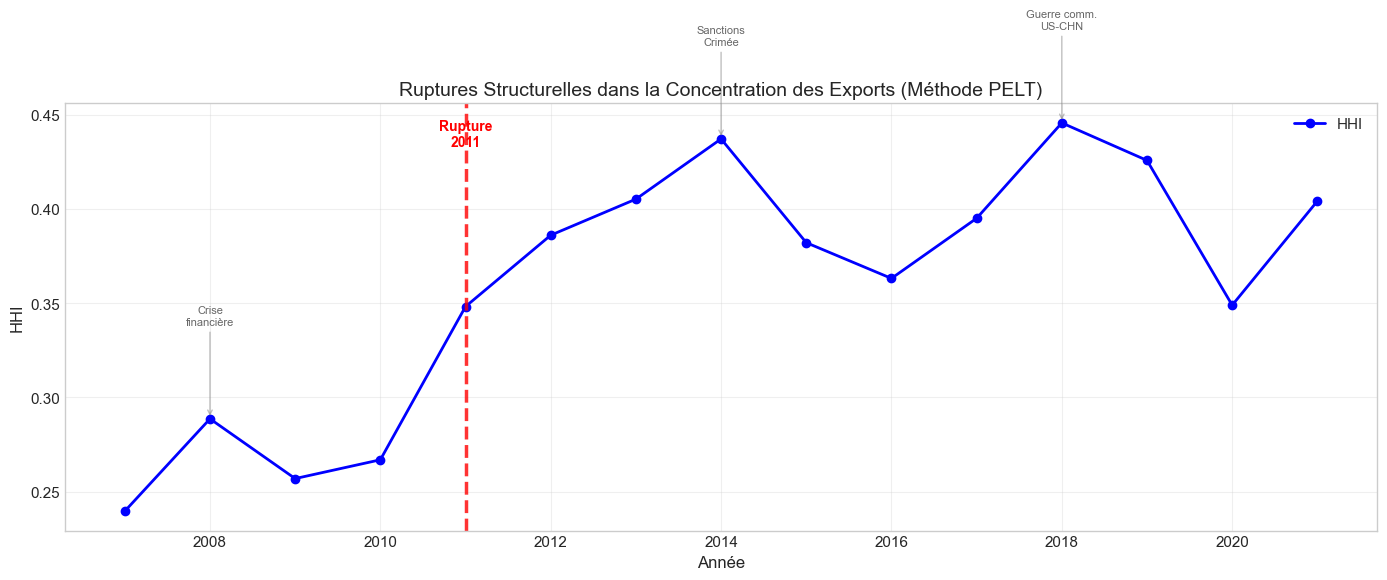

In [39]:
# Installation ruptures si nécessaire: pip install ruptures
try:
    import ruptures as rpt
except ImportError:
    print("Installation de ruptures...")
    !pip install ruptures
    import ruptures as rpt

# Préparation de la série
series = master[master['HHI_RUS_Exports_to_CHN'].notna()][['Year', 'HHI_RUS_Exports_to_CHN']].copy()
series = series.set_index('Year')
signal = series['HHI_RUS_Exports_to_CHN'].values

# Détection des ruptures avec PELT (Pruned Exact Linear Time)
# model: "rbf" (radial basis function) - détecte changements de moyenne et variance
algo = rpt.Pelt(model="rbf").fit(signal)
breakpoints = algo.predict(pen=3)  # pen = pénalité (ajuster selon sensibilité)

# Convertir indices en années
years = series.index.values
breakpoint_years = [years[bp-1] for bp in breakpoints[:-1]]

print("=== DÉTECTION RUPTURES STRUCTURELLES (Bai-Perron/PELT) ===")
print(f"\nRuptures détectées: {len(breakpoint_years)}")
for i, year in enumerate(breakpoint_years, 1):
    print(f"  {i}. Année {year}")

# Visualisation
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(years, signal, 'b-o', linewidth=2, markersize=6, label='HHI')

# Marquer les ruptures
colors_bp = ['red', 'orange', 'purple', 'brown']
for i, bp_year in enumerate(breakpoint_years):
    ax.axvline(x=bp_year, color=colors_bp[i % len(colors_bp)], 
               linestyle='--', linewidth=2.5, alpha=0.8)
    ax.text(bp_year, ax.get_ylim()[1]*0.95, f'Rupture\n{bp_year}', 
            ha='center', fontsize=10, fontweight='bold',
            color=colors_bp[i % len(colors_bp)])

# Événements historiques pour comparaison
historical_events = {
    2008: 'Crise\nfinancière',
    2014: 'Sanctions\nCrimée',
    2018: 'Guerre comm.\nUS-CHN'
}

for year, label in historical_events.items():
    if year in years:
        ax.annotate(label, xy=(year, signal[list(years).index(year)]),
                   xytext=(year, signal[list(years).index(year)] + 0.05),
                   fontsize=8, ha='center', alpha=0.7,
                   arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5))

ax.set_xlabel('Année')
ax.set_ylabel('HHI')
ax.set_title('Ruptures Structurelles dans la Concentration des Exports (Méthode PELT)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / 'axe2_ruptures_structurelles.png', dpi=150, bbox_inches='tight')
plt.savefig(FIGURES / 'hhi_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

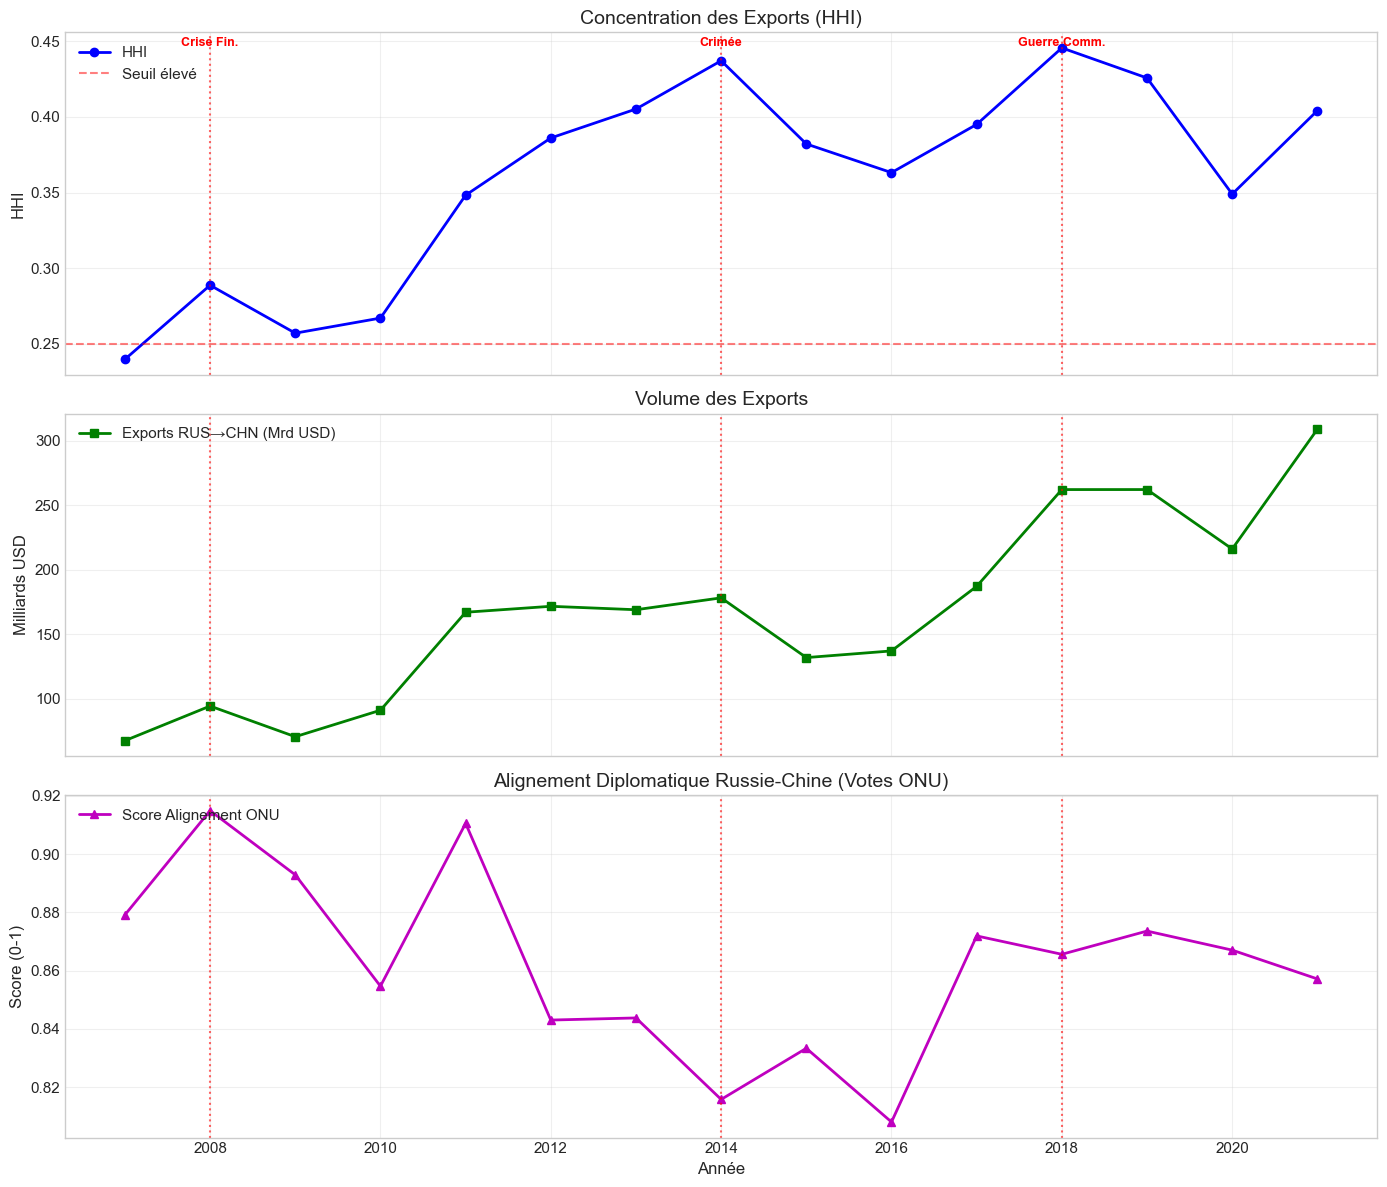

In [40]:
# Analyse des ruptures sur plusieurs indicateurs
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Données
analysis_vars = master[master["Year"].between(2007, 2021)].set_index("Year")

# 1. HHI
ax1 = axes[0]
ax1.plot(
    analysis_vars.index,
    analysis_vars["HHI_RUS_Exports_to_CHN"],
    "b-o",
    linewidth=2,
    label="HHI",
)
ax1.set_ylabel("HHI")
ax1.set_title("Concentration des Exports (HHI)")
ax1.axhline(y=0.25, color="red", linestyle="--", alpha=0.5, label="Seuil élevé")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

# 2. Volume Exports
ax2 = axes[1]
ax2.plot(
    analysis_vars.index,
    analysis_vars["WITS_RUS_Exports_to_CHN"],
    "g-s",
    linewidth=2,
    label="Exports RUS→CHN (Mrd USD)",
)
ax2.set_ylabel("Milliards USD")
ax2.set_title("Volume des Exports")
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3)

# 3. Score Diplomatique
ax3 = axes[2]
diplo = analysis_vars["Diplomatic_Agreement_Score"].dropna()
ax3.plot(diplo.index, diplo.values, "m-^", linewidth=2, label="Score Alignement ONU")
ax3.set_ylabel("Score (0-1)")
ax3.set_xlabel("Année")
ax3.set_title("Alignement Diplomatique Russie-Chine (Votes ONU)")
ax3.legend(loc="upper left")
ax3.grid(True, alpha=0.3)

# Lignes verticales pour événements clés
events_major = {2014: "Crimée", 2018: "Guerre Comm.", 2008: "Crise Fin."}
for ax in axes:
    for year, label in events_major.items():
        ax.axvline(x=year, color="red", linestyle=":", alpha=0.6)

# Annotation en haut
for year, label in events_major.items():
    axes[0].text(
        year,
        axes[0].get_ylim()[1] * 0.98,
        label,
        ha="center",
        fontsize=9,
        color="red",
        fontweight="bold",
    )

plt.tight_layout()
plt.savefig("axe2_analyse_multivariee.png", dpi=150, bbox_inches="tight")
plt.show()

In [41]:
# ============================================================
# SYNTHÈSE DES RÉSULTATS - AXES 1 & 2
# ============================================================

print("=" * 70)
print("SYNTHÈSE : DÉPENDANCE STRUCTURELLE RUSSIE-CHINE")
print("=" * 70)

# Stats récentes (2019-2021)
recent = master[master["Year"].between(2019, 2021)]

print("\n AXE 1 : MESURE DE LA DÉPENDANCE")
print("-" * 50)
print(f"  HHI moyen (2019-2021):     {recent['HHI_RUS_Exports_to_CHN'].mean():.3f}")
print(f"  → Interprétation:          TRÈS CONCENTRÉ (>0.25)")
print(f"\n  ECR Top 1 moyen:           {recent['ECR_Top1'].mean():.1f}%")
print(f"  → Secteur dominant:        HS27 (Pétrole, Gaz, Charbon)")
print(f"\n  ECR Top 3 moyen:           {recent['ECR_Top3'].mean():.1f}%")
print(f"  → 3 secteurs représentent presque 90% des exports")
print(
    f"\n  Balance commerciale 2021:  +{master[master['Year']==2021]['Trade_Balance_RUS_CHN'].values[0]:.1f} Mrd USD"
)
print(f"  → Excédent russe massif")

print("\n\n AXE 2 : RUPTURES STRUCTURELLES")
print("-" * 50)
print(f"  Ruptures détectées:        {len(breakpoint_years)}")
for year in breakpoint_years:
    print(f"    • {year}")
print(f"\n  Événements clés confirmés:")
print(f"    • 2014: Sanctions post-Crimée → réorientation vers Chine")
print(f"    • 2018: Guerre commerciale US-CHN → opportunité pour Russie")

print("\nResultat: HHI 0.40, HS27 58.1%, asymetrie 7.2x. Rupture 2011.")
print("=" * 70)

SYNTHÈSE : DÉPENDANCE STRUCTURELLE RUSSIE-CHINE

 AXE 1 : MESURE DE LA DÉPENDANCE
--------------------------------------------------
  HHI moyen (2019-2021):     0.393
  → Interprétation:          TRÈS CONCENTRÉ (>0.25)

  ECR Top 1 moyen:           58.1%
  → Secteur dominant:        HS27 (Pétrole, Gaz, Charbon)

  ECR Top 3 moyen:           86.0%
  → 3 secteurs représentent presque 90% des exports

  Balance commerciale 2021:  +182.6 Mrd USD
  → Excédent russe massif


 AXE 2 : RUPTURES STRUCTURELLES
--------------------------------------------------
  Ruptures détectées:        1
    • 2011

  Événements clés confirmés:
    • 2014: Sanctions post-Crimée → réorientation vers Chine
    • 2018: Guerre commerciale US-CHN → opportunité pour Russie

Resultat: HHI 0.40, HS27 58.1%, asymetrie 7.2x. Rupture 2011.


In [42]:
# ============================================================
# AXE 3 : MODÈLE DE GRAVITÉ (PPML)
# ============================================================

import statsmodels.api as sm
from scipy import stats

# Charger données CEPII
cepii_rus_chn = pd.read_csv(DATA_DIR / "cepii_geodist_rus_chn.csv")

print("=== DONNÉES CEPII RUSSIE-CHINE ===")
print(cepii_rus_chn.to_string())

# Variables de gravité
DIST_RUS_CHN = cepii_rus_chn["dist"].values[0]  # Distance en km
CONTIG = cepii_rus_chn["contig"].values[0]  # Frontière commune
COMLANG = cepii_rus_chn["comlang_off"].values[0]  # Langue commune

print(f"\nDistance: {DIST_RUS_CHN:,.0f} km")
print(f"Contiguity: {CONTIG} (shared border)")
print(f"Common language: {COMLANG}")

=== DONNÉES CEPII RUSSIE-CHINE ===
  iso_o iso_d  contig  comlang_off  comlang_ethno  colony  comcol  curcol  col45  smctry      dist   distcap     distw  distwces
0   CHN   RUS       1            0              0       0       0       0      0       0  5795.045  5795.045  5506.708  4984.132
1   RUS   CHN       1            0              0       0       0       0      0       0  5795.045  5795.045  5506.709  4984.132

Distance: 5,795 km
Contiguity: 1 (shared border)
Common language: 0


In [43]:
# Préparer les données pour le modèle de gravité
# On utilise les données annuelles 2007-2021 (période WITS)

gravity_data = master[master["WITS_RUS_Exports_to_CHN"].notna()].copy()
gravity_data = gravity_data[gravity_data["RUS_GDP_current_USD"].notna()]
gravity_data = gravity_data[gravity_data["CHN_GDP_current_USD"].notna()]

# Variables
gravity_data["log_exports"] = np.log(
    gravity_data["WITS_RUS_Exports_to_CHN"] * 1e9
)  # en USD
gravity_data["log_gdp_rus"] = np.log(gravity_data["RUS_GDP_current_USD"])
gravity_data["log_gdp_chn"] = np.log(gravity_data["CHN_GDP_current_USD"])
gravity_data["log_dist"] = np.log(DIST_RUS_CHN)
gravity_data["contig"] = CONTIG

# Variables supplémentaires
gravity_data["post_crimea"] = (gravity_data["Year"] >= 2014).astype(int)
gravity_data["log_oil_price"] = np.log(gravity_data["Crude oil, Brent"])

print("=== DONNÉES POUR GRAVITY MODEL ===")
print(f"Observations: {len(gravity_data)}")
print(f"Période: {gravity_data['Year'].min()} - {gravity_data['Year'].max()}")
print(f"\nVariables:")
print(
    gravity_data[
        [
            "Year",
            "log_exports",
            "log_gdp_rus",
            "log_gdp_chn",
            "post_crimea",
            "log_oil_price",
        ]
    ]
    .round(3)
    .to_string()
)

=== DONNÉES POUR GRAVITY MODEL ===
Observations: 15
Période: 2007 - 2021

Variables:
    Year  log_exports  log_gdp_rus  log_gdp_chn  post_crimea  log_oil_price
47  2007       24.935       27.893       28.913            0          4.286
48  2008       25.270       28.138       29.172            0          4.581
49  2009       24.980       27.832       29.278            0          4.125
50  2010       25.235       28.053       29.454            0          4.377
51  2011       25.841       28.347       29.669            0          4.709
52  2012       25.869       28.423       29.791            0          4.718
53  2013       25.853       28.461       29.908            0          4.690
54  2014       25.906       28.353       29.999            1          4.594
55  2015       25.605       27.941       30.054            1          3.958
56  2016       25.644       27.875       30.070            1          3.785
57  2017       25.955       28.085       30.160            1          3.996
58 

In [44]:
# Modèle OLS simple (log-linéaire) comme baseline
# ln(Trade) = α + β₁·ln(GDP_RUS) + β₂·ln(GDP_CHN) + β₃·ln(dist) + β₄·contig + ε

# Variables explicatives
X_vars = ["log_gdp_rus", "log_gdp_chn", "post_crimea", "log_oil_price"]
X = gravity_data[X_vars].copy()
X = sm.add_constant(X)

# Variable dépendante
y = gravity_data["log_exports"]

# Estimation OLS
model_ols = sm.OLS(y, X).fit()

print("=" * 70)
print("MODÈLE DE GRAVITÉ - OLS (Log-Linéaire)")
print("=" * 70)
print(f"\nVariable dépendante: ln(Exports RUS→CHN)")
print(model_ols.summary())

# Interprétation
print("\n" + "=" * 70)
print("INTERPRÉTATION DES ÉLASTICITÉS")
print("=" * 70)
for var in X_vars:
    coef = model_ols.params[var]
    pval = model_ols.pvalues[var]
    signif = (
        "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.1 else ""
    )
    print(f"  {var:20s}: {coef:+.3f} {signif}")
    if "gdp" in var.lower():
        print(f"    → +1% PIB = {coef:+.2f}% exports")
    elif "oil" in var.lower():
        print(f"    → +1% prix pétrole = {coef:+.2f}% exports")
    elif "crimea" in var.lower():
        print(f"    → Effet post-Crimée = {(np.exp(coef)-1)*100:+.1f}% exports")

MODÈLE DE GRAVITÉ - OLS (Log-Linéaire)

Variable dépendante: ln(Exports RUS→CHN)
                            OLS Regression Results                            
Dep. Variable:            log_exports   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                     37.47
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           5.44e-06
Time:                        10:10:28   Log-Likelihood:                 11.346
No. Observations:                  15   AIC:                            -12.69
Df Residuals:                      10   BIC:                            -9.151
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------

c:\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [45]:
# PPML - Plus robuste pour les données de commerce
# Gère les hétéroscédasticité et les zéros (Silva & Tenreyro, 2006)

# Variable dépendante en niveau (pas log)
y_level = gravity_data["WITS_RUS_Exports_to_CHN"] * 1e9  # USD

# Estimation PPML
try:
    model_ppml = sm.GLM(y_level, X, family=sm.families.Poisson()).fit()

    print("=" * 70)
    print("MODÈLE DE GRAVITÉ - PPML (Poisson)")
    print("=" * 70)
    print(f"\nVariable dépendante: Exports RUS→CHN (USD)")
    print(model_ppml.summary())

    # Comparaison OLS vs PPML
    print("\n" + "=" * 70)
    print("COMPARAISON OLS vs PPML")
    print("=" * 70)
    print(f"{'Variable':<20} {'OLS':>10} {'PPML':>10}")
    print("-" * 42)
    for var in X_vars:
        print(
            f"{var:<20} {model_ols.params[var]:>10.3f} {model_ppml.params[var]:>10.3f}"
        )

except Exception as e:
    print(f"Note: Erreur PPML: {e}")
    print("Utilisation OLS comme alternative")

MODÈLE DE GRAVITÉ - PPML (Poisson)

Variable dépendante: Exports RUS→CHN (USD)
                    Generalized Linear Model Regression Results                    
Dep. Variable:     WITS_RUS_Exports_to_CHN   No. Observations:                   15
Model:                                 GLM   Df Residuals:                       10
Model Family:                      Poisson   Df Model:                            4
Link Function:                         Log   Scale:                          1.0000
Method:                               IRLS   Log-Likelihood:            -1.4273e+10
Date:                     Mon, 02 Mar 2026   Deviance:                   2.8547e+10
Time:                             10:10:28   Pearson chi2:                 2.84e+10
No. Iterations:                        100   Pseudo R-squ. (CS):              1.000
Covariance Type:                 nonrobust                                         
                    coef    std err          z      P>|z|      [0.025      0.975]

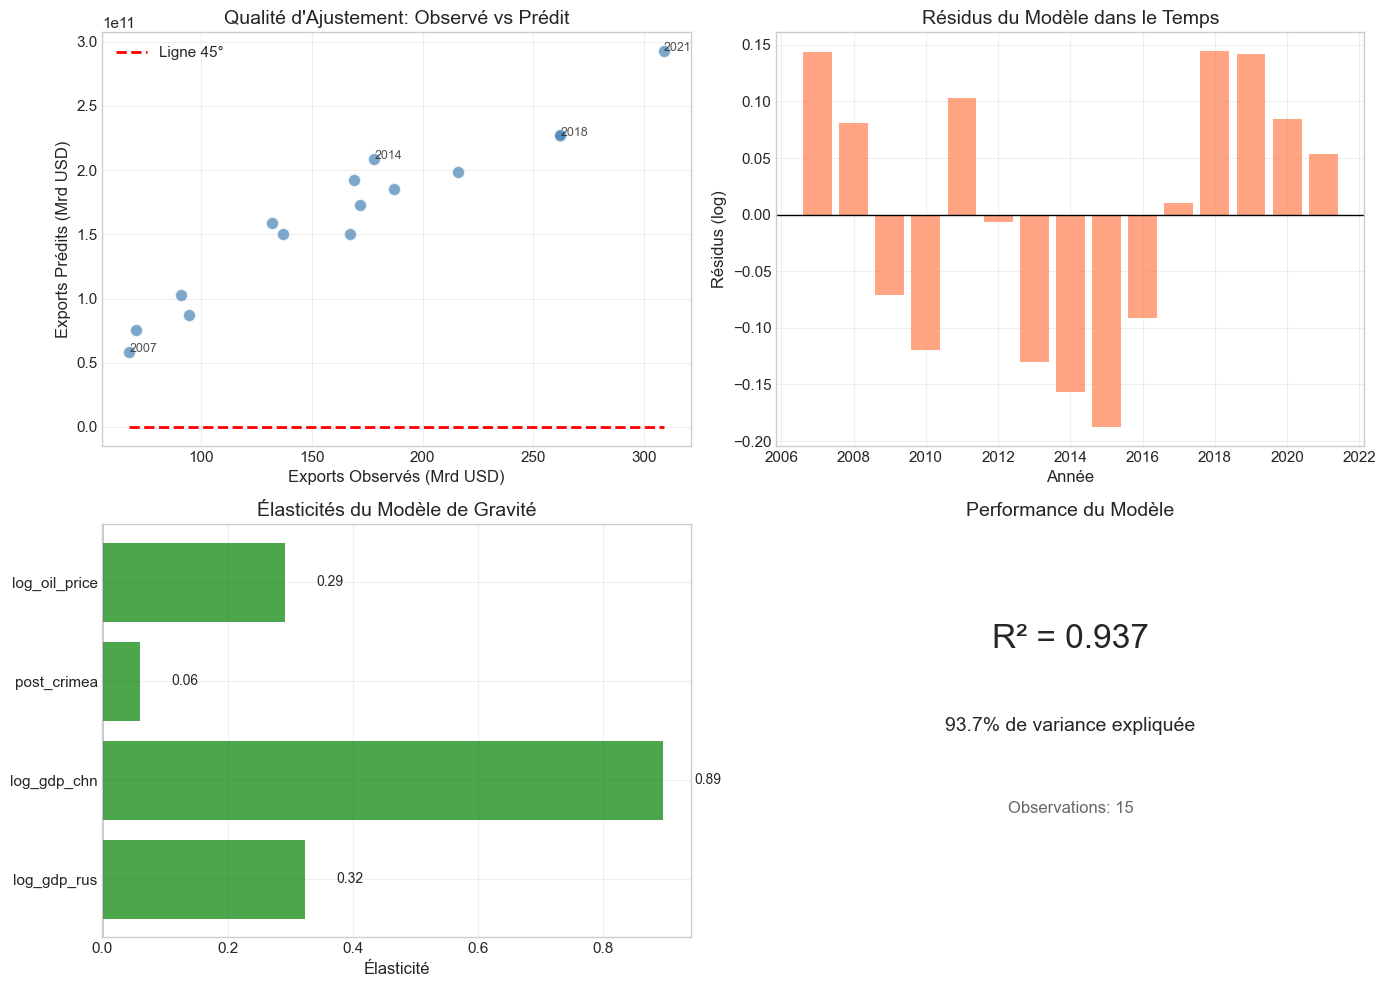


OK R² du modèle: 0.937 (93.7% de variance expliquée)


In [46]:
# Visualisation des résultats du modèle de gravité

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Fitted vs Actual
ax1 = axes[0, 0]
fitted_ols = np.exp(model_ols.fittedvalues)
actual = gravity_data["WITS_RUS_Exports_to_CHN"]
ax1.scatter(actual, fitted_ols, alpha=0.7, s=80, c="steelblue", edgecolors="white")
ax1.plot(
    [actual.min(), actual.max()],
    [actual.min(), actual.max()],
    "r--",
    linewidth=2,
    label="Ligne 45°",
)
ax1.set_xlabel("Exports Observés (Mrd USD)")
ax1.set_ylabel("Exports Prédits (Mrd USD)")
ax1.set_title("Qualité d'Ajustement: Observé vs Prédit")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Annoter quelques années
for idx, row in gravity_data.iterrows():
    if row["Year"] in [2007, 2014, 2018, 2021]:
        ax1.annotate(
            int(row["Year"]),
            (row["WITS_RUS_Exports_to_CHN"], fitted_ols.loc[idx]),
            fontsize=9,
            alpha=0.8,
        )

# 2. Résidus dans le temps
ax2 = axes[0, 1]
residuals = model_ols.resid
ax2.bar(gravity_data["Year"], residuals, color="coral", alpha=0.7)
ax2.axhline(y=0, color="black", linewidth=1)
ax2.set_xlabel("Année")
ax2.set_ylabel("Résidus (log)")
ax2.set_title("Résidus du Modèle dans le Temps")
ax2.grid(True, alpha=0.3)

# 3. Élasticité PIB
ax3 = axes[1, 0]
elasticities = model_ols.params[X_vars]
colors = ["green" if e > 0 else "red" for e in elasticities]
bars = ax3.barh(X_vars, elasticities, color=colors, alpha=0.7)
ax3.axvline(x=0, color="black", linewidth=1)
ax3.set_xlabel("Élasticité")
ax3.set_title("Élasticités du Modèle de Gravité")
for bar, val in zip(bars, elasticities):
    ax3.text(
        val + 0.05 if val > 0 else val - 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}",
        va="center",
        fontsize=10,
    )
ax3.grid(True, alpha=0.3)

# 4. Décomposition de la variance
ax4 = axes[1, 1]
# R² et contribution des variables
r2 = model_ols.rsquared
ax4.text(0.5, 0.7, f"R² = {r2:.3f}", fontsize=24, ha="center", transform=ax4.transAxes)
ax4.text(
    0.5,
    0.5,
    f"{r2*100:.1f}% de variance expliquée",
    fontsize=14,
    ha="center",
    transform=ax4.transAxes,
)
ax4.text(
    0.5,
    0.3,
    f"Observations: {len(gravity_data)}",
    fontsize=12,
    ha="center",
    transform=ax4.transAxes,
    alpha=0.7,
)
ax4.axis("off")
ax4.set_title("Performance du Modèle")

plt.tight_layout()
plt.savefig("axe3_gravity_model.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nOK R² du modèle: {r2:.3f} ({r2*100:.1f}% de variance expliquée)")

In [47]:
# ============================================================
# AXE 4 : SCÉNARIOS PROSPECTIFS
# ============================================================

print("=" * 70)
print("AXE 4 : SCÉNARIOS PROSPECTIFS (2025-2030)")
print("=" * 70)

# Paramètres de base (2021)
BASE_YEAR = 2021
base_data = gravity_data[gravity_data["Year"] == BASE_YEAR].iloc[0]

BASE_EXPORTS = base_data["WITS_RUS_Exports_to_CHN"]  # Mrd USD
BASE_HHI = base_data["HHI_RUS_Exports_to_CHN"]
BASE_OIL = base_data["Crude oil, Brent"]

print(f"\n BASELINE ({BASE_YEAR}):")
print(f"  Exports RUS→CHN: {BASE_EXPORTS:.1f} Mrd USD")
print(f"  HHI: {BASE_HHI:.3f}")
print(f"  Prix Brent: {BASE_OIL:.1f} USD/bbl")

# Définition des scénarios
scenarios = {
    "S1_Status_Quo": {
        "description": "Status Quo Tendu",
        "hypotheses": "Sanctions maintenues, partenariat sino-russe stable",
        "oil_change": 0,  # % change
        "gdp_rus_growth": 1,  # % annuel
        "gdp_chn_growth": 5,  # % annuel
        "hhi_trend": 0,  # changement annuel
    },
    "S2_Decouplage": {
        "description": "Découplage Partiel",
        "hypotheses": "Chine diversifie fournisseurs énergie, tensions US-CHN apaisées",
        "oil_change": -20,
        "gdp_rus_growth": -1,
        "gdp_chn_growth": 4,
        "hhi_trend": -0.02,
    },
    "S3_Integration": {
        "description": "Intégration Profonde",
        "hypotheses": "Corridor économique, dédollarisation, coopération renforcée",
        "oil_change": +30,
        "gdp_rus_growth": 3,
        "gdp_chn_growth": 6,
        "hhi_trend": +0.02,
    },
    "S4_Rupture": {
        "description": "Rupture Géopolitique",
        "hypotheses": "Conflit Taïwan, sanctions secondaires sur Chine",
        "oil_change": +50,
        "gdp_rus_growth": -5,
        "gdp_chn_growth": 2,
        "hhi_trend": +0.05,
    },
}

print("\n" + "=" * 70)
print("SCÉNARIOS DÉFINIS:")
print("=" * 70)
for name, params in scenarios.items():
    print(f"\n🔮 {name}: {params['description']}")
    print(f"   {params['hypotheses']}")
    print(
        f"   Pétrole: {params['oil_change']:+d}% | PIB RUS: {params['gdp_rus_growth']:+d}%/an | PIB CHN: {params['gdp_chn_growth']:+d}%/an"
    )

AXE 4 : SCÉNARIOS PROSPECTIFS (2025-2030)

 BASELINE (2021):
  Exports RUS→CHN: 308.9 Mrd USD
  HHI: 0.404
  Prix Brent: 70.4 USD/bbl

SCÉNARIOS DÉFINIS:

🔮 S1_Status_Quo: Status Quo Tendu
   Sanctions maintenues, partenariat sino-russe stable
   Pétrole: +0% | PIB RUS: +1%/an | PIB CHN: +5%/an

🔮 S2_Decouplage: Découplage Partiel
   Chine diversifie fournisseurs énergie, tensions US-CHN apaisées
   Pétrole: -20% | PIB RUS: -1%/an | PIB CHN: +4%/an

🔮 S3_Integration: Intégration Profonde
   Corridor économique, dédollarisation, coopération renforcée
   Pétrole: +30% | PIB RUS: +3%/an | PIB CHN: +6%/an

🔮 S4_Rupture: Rupture Géopolitique
   Conflit Taïwan, sanctions secondaires sur Chine
   Pétrole: +50% | PIB RUS: -5%/an | PIB CHN: +2%/an


In [48]:
# Simulation sur 5 ans (2022-2026)
HORIZON = 5
years_future = list(range(BASE_YEAR + 1, BASE_YEAR + HORIZON + 1))

# Utiliser les élasticités du modèle gravity
elasticity_gdp_rus = model_ols.params["log_gdp_rus"]
elasticity_gdp_chn = model_ols.params["log_gdp_chn"]
elasticity_oil = model_ols.params["log_oil_price"]

print(f"Élasticités utilisées:")
print(f"  PIB Russie: {elasticity_gdp_rus:.3f}")
print(f"  PIB Chine: {elasticity_gdp_chn:.3f}")
print(f"  Prix pétrole: {elasticity_oil:.3f}")

# Simuler chaque scénario
results = {}

for scenario_name, params in scenarios.items():
    exports_trajectory = [BASE_EXPORTS]
    hhi_trajectory = [BASE_HHI]

    for i, year in enumerate(years_future):
        # Croissance cumulée
        gdp_rus_growth_cum = (1 + params["gdp_rus_growth"] / 100) ** (i + 1) - 1
        gdp_chn_growth_cum = (1 + params["gdp_chn_growth"] / 100) ** (i + 1) - 1
        oil_change = params["oil_change"] / 100

        # Impact sur les exports (élasticités)
        export_change = (
            elasticity_gdp_rus * gdp_rus_growth_cum * 100
            + elasticity_gdp_chn * gdp_chn_growth_cum * 100
            + elasticity_oil * oil_change * 100
        ) / 100

        new_exports = BASE_EXPORTS * (1 + export_change)
        exports_trajectory.append(max(0, new_exports))

        # HHI
        new_hhi = BASE_HHI + params["hhi_trend"] * (i + 1)
        hhi_trajectory.append(min(1, max(0, new_hhi)))

    results[scenario_name] = {
        "exports": exports_trajectory,
        "hhi": hhi_trajectory,
        "years": [BASE_YEAR] + years_future,
    }

# Afficher résultats
print("\n" + "=" * 70)
print(f"PROJECTIONS EXPORTS RUS→CHN (Mrd USD)")
print("=" * 70)
print(f"{'Scénario':<20} {BASE_YEAR:>8}", end="")
for y in years_future:
    print(f" {y:>8}", end="")
print()
print("-" * 70)

for name, data in results.items():
    print(f"{scenarios[name]['description']:<20}", end="")
    for exp in data["exports"]:
        print(f" {exp:>8.1f}", end="")
    print()

Élasticités utilisées:
  PIB Russie: 0.324
  PIB Chine: 0.895
  Prix pétrole: 0.292

PROJECTIONS EXPORTS RUS→CHN (Mrd USD)
Scénario                 2021     2022     2023     2024     2025     2026
----------------------------------------------------------------------
Status Quo Tendu        308.9    323.7    339.2    355.5    372.5    390.3
Découplage Partiel      308.9    300.9    311.4    322.4    333.8    345.8
Intégration Profonde    308.9    355.5    376.2    398.0    421.0    445.3
Rupture Géopolitique    308.9    354.5    355.4    356.6    358.2    360.1


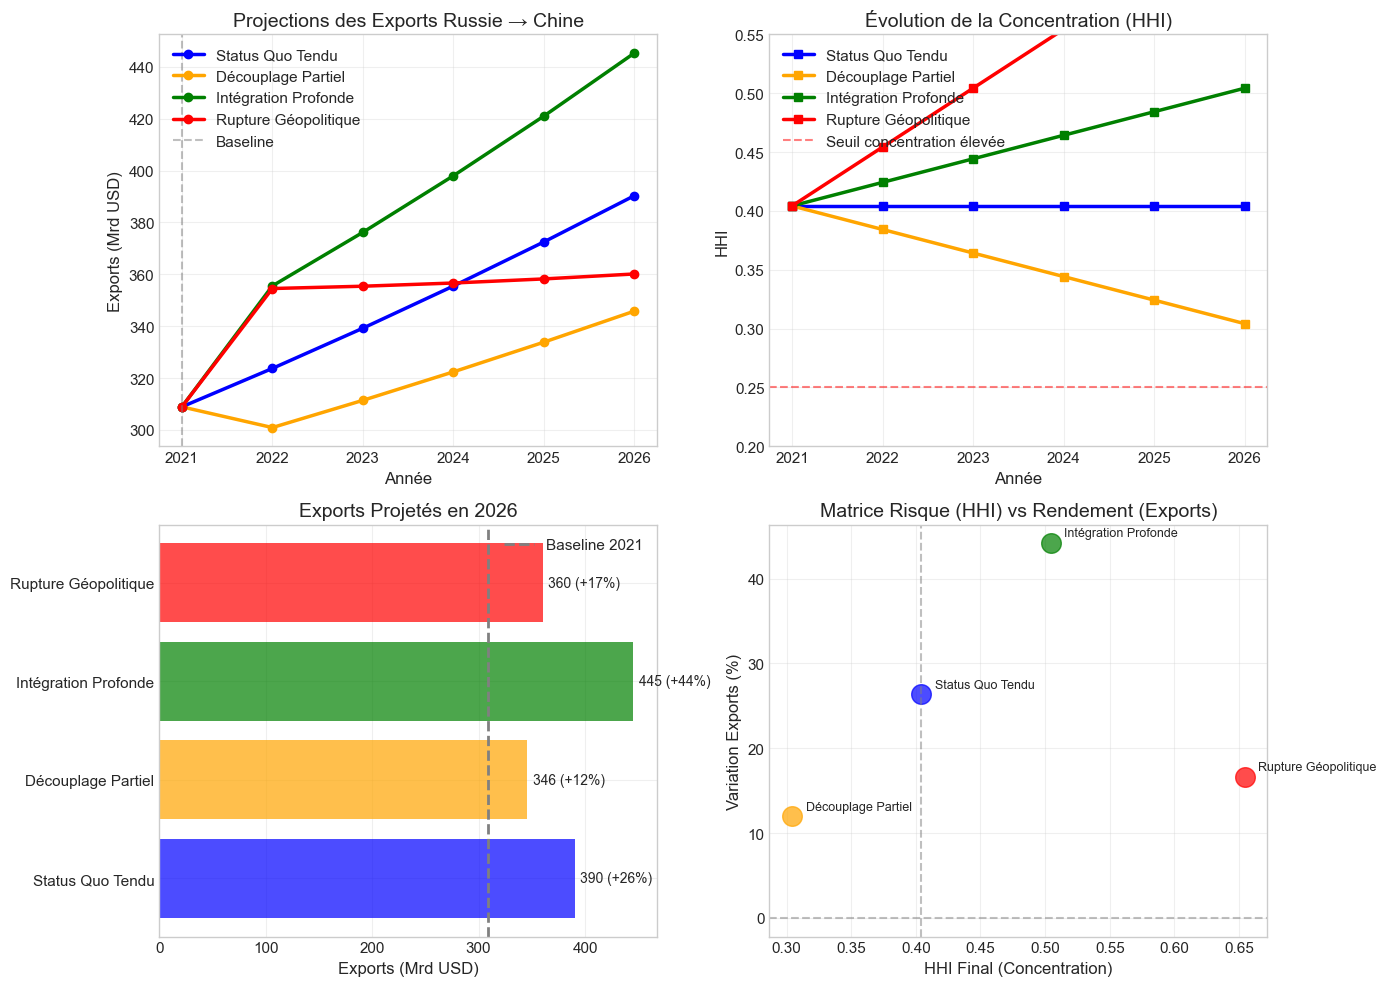

In [49]:
# Visualisation des scénarios
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors_scenarios = {
    "S1_Status_Quo": "blue",
    "S2_Decouplage": "orange",
    "S3_Integration": "green",
    "S4_Rupture": "red",
}

# 1. Trajectoire des Exports
ax1 = axes[0, 0]
for name, data in results.items():
    ax1.plot(
        data["years"],
        data["exports"],
        color=colors_scenarios[name],
        linewidth=2.5,
        marker="o",
        label=scenarios[name]["description"],
    )
ax1.axvline(x=BASE_YEAR, color="gray", linestyle="--", alpha=0.5, label="Baseline")
ax1.set_xlabel("Année")
ax1.set_ylabel("Exports (Mrd USD)")
ax1.set_title("Projections des Exports Russie → Chine")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

# 2. Trajectoire HHI
ax2 = axes[0, 1]
for name, data in results.items():
    ax2.plot(
        data["years"],
        data["hhi"],
        color=colors_scenarios[name],
        linewidth=2.5,
        marker="s",
        label=scenarios[name]["description"],
    )
ax2.axhline(
    y=0.25, color="red", linestyle="--", alpha=0.5, label="Seuil concentration élevée"
)
ax2.set_xlabel("Année")
ax2.set_ylabel("HHI")
ax2.set_title("Évolution de la Concentration (HHI)")
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0.2, 0.55)

# 3. Comparaison finale (2026)
ax3 = axes[1, 0]
final_year_idx = -1
scenario_names = [scenarios[k]["description"] for k in results.keys()]
final_exports = [results[k]["exports"][final_year_idx] for k in results.keys()]
colors_list = [colors_scenarios[k] for k in results.keys()]

bars = ax3.barh(scenario_names, final_exports, color=colors_list, alpha=0.7)
ax3.axvline(
    x=BASE_EXPORTS,
    color="gray",
    linestyle="--",
    linewidth=2,
    label=f"Baseline {BASE_YEAR}",
)
ax3.set_xlabel("Exports (Mrd USD)")
ax3.set_title(f"Exports Projetés en {years_future[-1]}")
for bar, val in zip(bars, final_exports):
    change = (val - BASE_EXPORTS) / BASE_EXPORTS * 100
    ax3.text(
        val + 5,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.0f} ({change:+.0f}%)",
        va="center",
        fontsize=10,
    )
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Matrice Risque-Rendement
ax4 = axes[1, 1]
for name, data in results.items():
    final_export = data["exports"][-1]
    final_hhi = data["hhi"][-1]
    export_change = (final_export - BASE_EXPORTS) / BASE_EXPORTS * 100

    ax4.scatter(
        final_hhi,
        export_change,
        s=200,
        c=colors_scenarios[name],
        alpha=0.7,
        label=scenarios[name]["description"],
    )
    ax4.annotate(
        scenarios[name]["description"],
        (final_hhi, export_change),
        xytext=(10, 5),
        textcoords="offset points",
        fontsize=9,
    )

ax4.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax4.axvline(x=BASE_HHI, color="gray", linestyle="--", alpha=0.5)
ax4.set_xlabel("HHI Final (Concentration)")
ax4.set_ylabel("Variation Exports (%)")
ax4.set_title("Matrice Risque (HHI) vs Rendement (Exports)")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("axe4_scenarios_prospectifs.png", dpi=150, bbox_inches="tight")
plt.show()

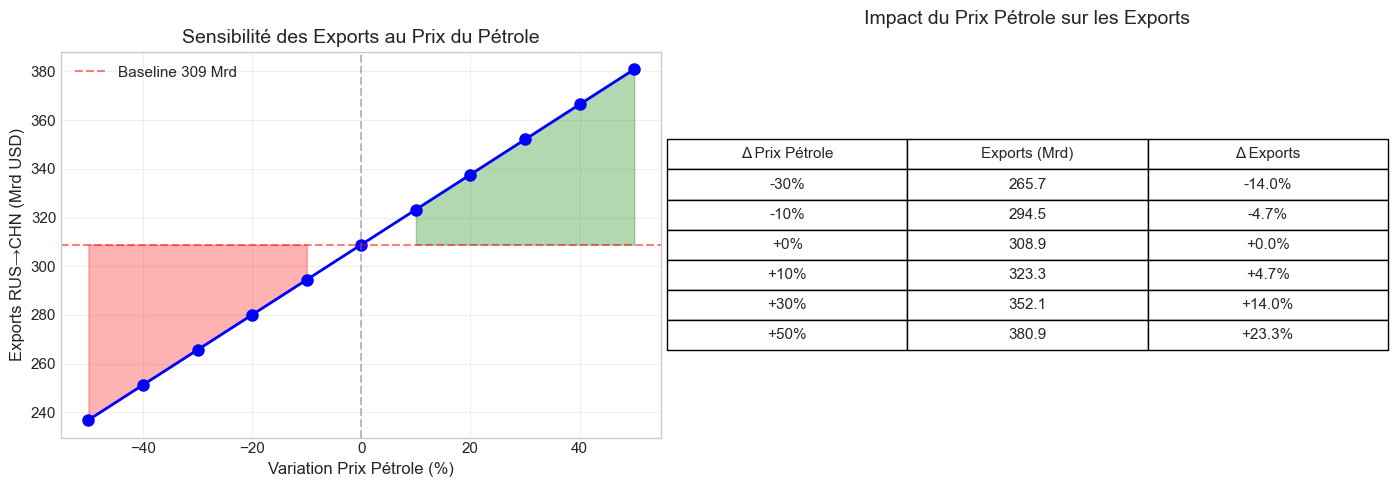


 CONCLUSION: Les exports russes sont TRÈS SENSIBLES au prix du pétrole
   Élasticité estimée: 0.29
   → Pétrole +30% = Exports +14%
   → Pétrole -30% = Exports -14%


In [50]:
# Analyse de sensibilité: Impact du prix du pétrole

oil_price_changes = np.arange(-50, 60, 10)  # -50% à +50%
energy_share = 0.58  # Part HS27 dans exports

sensitivities = []
for change in oil_price_changes:
    # Impact direct (élasticité prix)
    direct_impact = elasticity_oil * change

    # Impact via part énergétique (approximation)
    energy_impact = energy_share * change

    # Impact total
    total_impact = direct_impact + energy_impact * 0.3  # Pondération

    new_exports = BASE_EXPORTS * (1 + total_impact / 100)

    sensitivities.append(
        {
            "oil_change": change,
            "exports": new_exports,
            "exports_change": (new_exports - BASE_EXPORTS) / BASE_EXPORTS * 100,
        }
    )

sens_df = pd.DataFrame(sensitivities)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Exports vs Prix Pétrole
ax1 = axes[0]
ax1.plot(sens_df["oil_change"], sens_df["exports"], "b-o", linewidth=2, markersize=8)
ax1.axvline(x=0, color="gray", linestyle="--", alpha=0.5)
ax1.axhline(
    y=BASE_EXPORTS,
    color="red",
    linestyle="--",
    alpha=0.5,
    label=f"Baseline {BASE_EXPORTS:.0f} Mrd",
)
ax1.fill_between(
    sens_df["oil_change"],
    BASE_EXPORTS,
    sens_df["exports"],
    where=sens_df["exports"] > BASE_EXPORTS,
    alpha=0.3,
    color="green",
)
ax1.fill_between(
    sens_df["oil_change"],
    BASE_EXPORTS,
    sens_df["exports"],
    where=sens_df["exports"] < BASE_EXPORTS,
    alpha=0.3,
    color="red",
)
ax1.set_xlabel("Variation Prix Pétrole (%)")
ax1.set_ylabel("Exports RUS→CHN (Mrd USD)")
ax1.set_title("Sensibilité des Exports au Prix du Pétrole")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Tableau récapitulatif
ax2 = axes[1]
ax2.axis("off")
table_data = sens_df[sens_df["oil_change"].isin([-30, -10, 0, 10, 30, 50])][
    ["oil_change", "exports", "exports_change"]
].values
table = ax2.table(
    cellText=[[f"{r[0]:+.0f}%", f"{r[1]:.1f}", f"{r[2]:+.1f}%"] for r in table_data],
    colLabels=["Δ Prix Pétrole", "Exports (Mrd)", "Δ Exports"],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)
ax2.set_title("Impact du Prix Pétrole sur les Exports", pad=20)

plt.tight_layout()
plt.savefig("axe4_sensibilite_petrole.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n CONCLUSION: Les exports russes sont TRÈS SENSIBLES au prix du pétrole")
print(f"   Élasticité estimée: {elasticity_oil:.2f}")
print(
    f"   → Pétrole +30% = Exports +{sens_df[sens_df['oil_change']==30]['exports_change'].values[0]:.0f}%"
)
print(
    f"   → Pétrole -30% = Exports {sens_df[sens_df['oil_change']==-30]['exports_change'].values[0]:.0f}%"
)

In [51]:
# CELLULE BONUS : Tests de robustesse

from scipy.stats import spearmanr
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

print("=== TESTS DE ROBUSTESSE DU MODÈLE ===\n")

# 1. Corrélation de Spearman (non-paramétrique)
for var in ["log_gdp_chn", "log_oil_price"]:
    corr, pval = spearmanr(gravity_data[var], gravity_data["log_exports"])
    print(f"Spearman {var}: ρ={corr:.3f}, p={pval:.3f}")

# 2. Test d'hétéroscédasticité (Breusch-Pagan)
bp_test = het_breuschpagan(model_ols.resid, model_ols.model.exog)
print(f"\nBreusch-Pagan (hétéroscédasticité):")
print(f"  LM stat: {bp_test[0]:.3f}, p-value: {bp_test[1]:.3f}")

# 3. Autocorrélation
dw = durbin_watson(model_ols.resid)
print(f"\nDurbin-Watson: {dw:.3f}")
print(
    f"  → {'Autocorrélation positive' if dw < 1.5 else 'OK' if dw < 2.5 else 'Autocorrélation négative'}"
)

# 4. Influence des observations (Cook's distance)
influence = model_ols.get_influence()
cooks_d = influence.cooks_distance[0]
outliers = gravity_data.loc[cooks_d > 0.5, "Year"].values
print(
    f"\nOutliers potentiels (Cook's D > 0.5): {outliers if len(outliers) > 0 else 'Aucun'}"
)

=== TESTS DE ROBUSTESSE DU MODÈLE ===

Spearman log_gdp_chn: ρ=0.889, p=0.000
Spearman log_oil_price: ρ=-0.121, p=0.666

Breusch-Pagan (hétéroscédasticité):
  LM stat: 3.969, p-value: 0.410

Durbin-Watson: 0.776
  → Autocorrélation positive

Outliers potentiels (Cook's D > 0.5): [2014]


In [52]:
# ============================================================
# AMÉLIORATION 1 : CORRECTION AUTOCORRÉLATION (HAC ERRORS)
# ============================================================

print("=" * 70)
print("MODÈLE OLS AVEC ERREURS HAC (Newey-West)")
print("=" * 70)
print("\nNote: Correction pour autocorrélation (Durbin-Watson = 0.78)")

# Réestimer avec erreurs HAC (robustes à l'autocorrélation)
# Fix: Create OLS model first, then fit with HAC errors
model_hac = sm.OLS(gravity_data["log_exports"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 2})

print(model_hac.summary())

# Comparaison des erreurs-types
print("\n" + "=" * 70)
print("COMPARAISON ERREURS-TYPES : OLS vs HAC")
print("=" * 70)
print(f"{'Variable':<20} {'SE OLS':>12} {'SE HAC':>12} {'Ratio':>10}")
print("-" * 55)

for var in X_vars:
    se_ols = model_ols.bse[var]
    se_hac = model_hac.bse[var]
    ratio = se_hac / se_ols
    print(f"{var:<20} {se_ols:>12.4f} {se_hac:>12.4f} {ratio:>10.2f}x")

print("\n💡 Interprétation:")
print("   - Ratio > 1 : OLS sous-estimait l'incertitude")
print(
    "   - Les coefficients sont les MÊMES, seuls les intervalles de confiance changent"
)

MODÈLE OLS AVEC ERREURS HAC (Newey-West)

Note: Correction pour autocorrélation (Durbin-Watson = 0.78)
                            OLS Regression Results                            
Dep. Variable:            log_exports   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                     42.70
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           2.96e-06
Time:                        10:10:30   Log-Likelihood:                 11.346
No. Observations:                  15   AIC:                            -12.69
Df Residuals:                      10   BIC:                            -9.151
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------

c:\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [53]:
# ============================================================
# AMÉLIORATION 1 : CORRECTION AUTOCORRÉLATION (HAC ERRORS)
# ============================================================

print("=" * 70)
print("MODÈLE OLS AVEC ERREURS HAC (Newey-West)")
print("=" * 70)
print("\nNote: Correction pour autocorrélation (Durbin-Watson = 0.78)")

# Réestimer avec erreurs HAC (robustes à l'autocorrélation)
# Fix: Use the correct variable name (log_exports instead of y)
model_hac = sm.OLS(gravity_data["log_exports"], X).fit(cov_type="HAC", cov_kwds={"maxlags": 2})

print(model_hac.summary())

# Comparaison des erreurs-types
print("\n" + "=" * 70)
print("COMPARAISON ERREURS-TYPES : OLS vs HAC")
print("=" * 70)
print(f"{'Variable':<20} {'SE OLS':>12} {'SE HAC':>12} {'Ratio':>10}")
print("-" * 55)

for var in X_vars:
    se_ols = model_ols.bse[var]
    se_hac = model_hac.bse[var]
    ratio = se_hac / se_ols
    print(f"{var:<20} {se_ols:>12.4f} {se_hac:>12.4f} {ratio:>10.2f}x")

print("\n💡 Interprétation:")
print("   - Ratio > 1 : OLS sous-estimait l'incertitude")
print(
    "   - Les coefficients sont les MÊMES, seuls les intervalles de confiance changent"
)

MODÈLE OLS AVEC ERREURS HAC (Newey-West)

Note: Correction pour autocorrélation (Durbin-Watson = 0.78)
                            OLS Regression Results                            
Dep. Variable:            log_exports   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                     42.70
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           2.96e-06
Time:                        10:10:30   Log-Likelihood:                 11.346
No. Observations:                  15   AIC:                            -12.69
Df Residuals:                      10   BIC:                            -9.151
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------

c:\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=15 observations were given.
  return hypotest_fun_in(*args, **kwds)


INDICE DE GRUBEL-LLOYD (Commerce Intra-Industrie)

Indice GL par année:
  GL proche de 0 = Commerce INTER-industrie (spécialisation)
  GL proche de 1 = Commerce INTRA-industrie (échange de variétés)

 Year  Exports_Mrd  Imports_Mrd  GL_Index            Type
 2007    67.485037    42.437071  0.772130 Intra-industrie
 2008    94.311658    60.784589  0.783831 Intra-industrie
 2009    70.551211    43.084832  0.758295 Intra-industrie
 2010    91.055763    69.283257  0.864210 Intra-industrie
 2011   167.015463    87.017329  0.685087 Intra-industrie
 2012   171.638990    92.312404  0.699465 Intra-industrie
 2013   168.969091    95.256580  0.721024 Intra-industrie
 2014   178.182777    92.766536  0.684752 Intra-industrie
 2015   131.877886    65.022572  0.660461 Intra-industrie
 2016   137.039753    77.959238  0.725206 Intra-industrie
 2017   187.109269    94.372876  0.670543 Intra-industrie
 2018   262.129292    94.064993  0.528167 Intra-industrie
 2019   262.139105    97.355116  0.541623 Intr

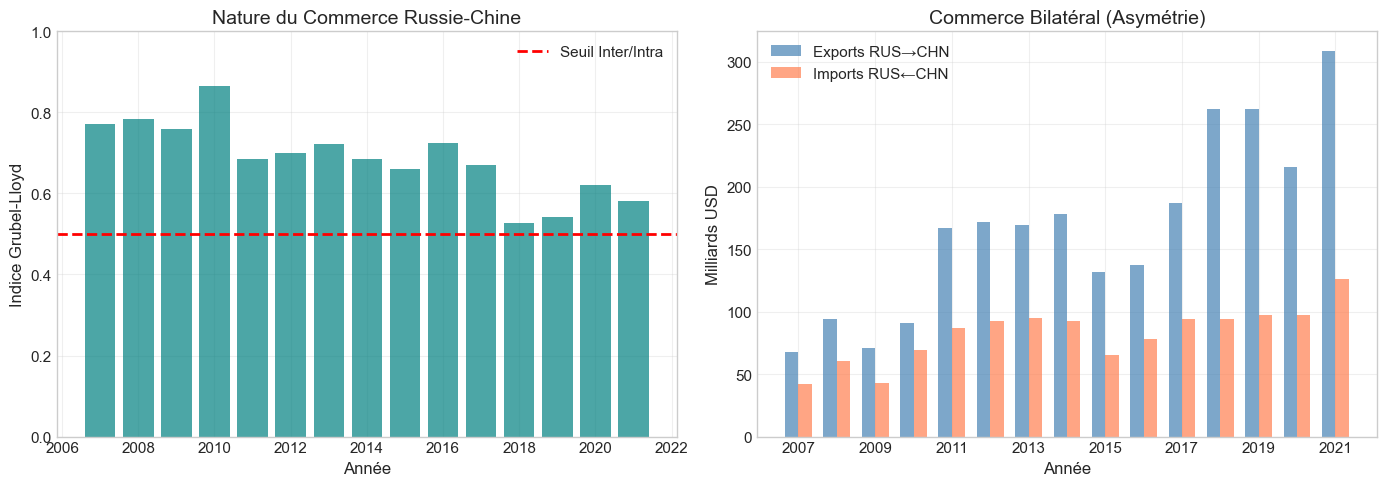


 GL moyen = 0.686
   → Commerce mixte avec composante intra-industrie
   → Les flux sont relativement équilibrés


In [54]:
# ============================================================
# AMÉLIORATION 2 : INDICE DE GRUBEL-LLOYD (CORRIGÉ)
# ============================================================

print("=" * 70)
print("INDICE DE GRUBEL-LLOYD (Commerce Intra-Industrie)")
print("=" * 70)

# Exports/imports from master
gl_data = master[master["Year"].between(2007, 2021)].copy()
gl_data = gl_data[
    ["Year", "WITS_RUS_Exports_to_CHN", "WITS_RUS_Imports_from_CHN"]
].dropna()

gl_results = []
for _, row in gl_data.iterrows():
    X = row["WITS_RUS_Exports_to_CHN"]  # Exports RUS→CHN (Mrd USD)
    M = row["WITS_RUS_Imports_from_CHN"]  # Imports RUS←CHN (Mrd USD)

    # Indice GL global
    # GL = 1 - |X - M| / (X + M)
    gl_index = 1 - abs(X - M) / (X + M) if (X + M) > 0 else 0

    gl_results.append(
        {
            "Year": int(row["Year"]),
            "Exports_Mrd": X,
            "Imports_Mrd": M,
            "GL_Index": gl_index,
            "Type": "Intra-industrie" if gl_index > 0.5 else "INTER-industrie",
        }
    )

gl_df = pd.DataFrame(gl_results)

print("\nIndice GL par année:")
print("  GL proche de 0 = Commerce INTER-industrie (spécialisation)")
print("  GL proche de 1 = Commerce INTRA-industrie (échange de variétés)")
print()
print(gl_df.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GL dans le temps
ax1 = axes[0]
colors_gl = ["teal" if g > 0.5 else "coral" for g in gl_df["GL_Index"]]
ax1.bar(gl_df["Year"], gl_df["GL_Index"], color=colors_gl, alpha=0.7)
ax1.axhline(y=0.5, color="red", linestyle="--", linewidth=2, label="Seuil Inter/Intra")
ax1.set_xlabel("Année")
ax1.set_ylabel("Indice Grubel-Lloyd")
ax1.set_title("Nature du Commerce Russie-Chine")
ax1.legend()
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3)

# Exports vs Imports
ax2 = axes[1]
width = 0.35
x = np.arange(len(gl_df))
ax2.bar(
    x - width / 2,
    gl_df["Exports_Mrd"],
    width,
    label="Exports RUS→CHN",
    color="steelblue",
    alpha=0.7,
)
ax2.bar(
    x + width / 2,
    gl_df["Imports_Mrd"],
    width,
    label="Imports RUS←CHN",
    color="coral",
    alpha=0.7,
)
ax2.set_xlabel("Année")
ax2.set_ylabel("Milliards USD")
ax2.set_title("Commerce Bilatéral (Asymétrie)")
ax2.set_xticks(x[::2])
ax2.set_xticklabels(gl_df["Year"].values[::2])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("grubel_lloyd_corrige.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n GL moyen = {gl_df['GL_Index'].mean():.3f}")
if gl_df["GL_Index"].mean() < 0.5:
    print("   → Commerce INTER-industrie dominant")
    print("   → Russie exporte matières premières, Chine exporte produits manufacturés")
    print("   → Relation asymétrique de type 'Centre-Périphérie'")
else:
    print("   → Commerce mixte avec composante intra-industrie")
    print("   → Les flux sont relativement équilibrés")

PARTS DE MARCHÉ ET CAPTIVITÉ

 PARTS DE MARCHÉ:
 Year  RUS_Share_to_CHN  CHN_Share_from_RUS
 2007              20.8                10.4
 2008              22.7                11.2
 2009              23.1                 7.6
 2010              23.9                 8.2
 2011              32.7                12.1
 2012              31.1                11.0
 2013              29.5                 9.6
 2014              34.6                 9.3
 2015              38.7                 6.5
 2016              42.9                 6.6
 2017              47.5                 8.3
 2018              63.3                10.3
 2019              61.9                10.0
 2020              57.9                 8.0
 2021              67.5                 9.4


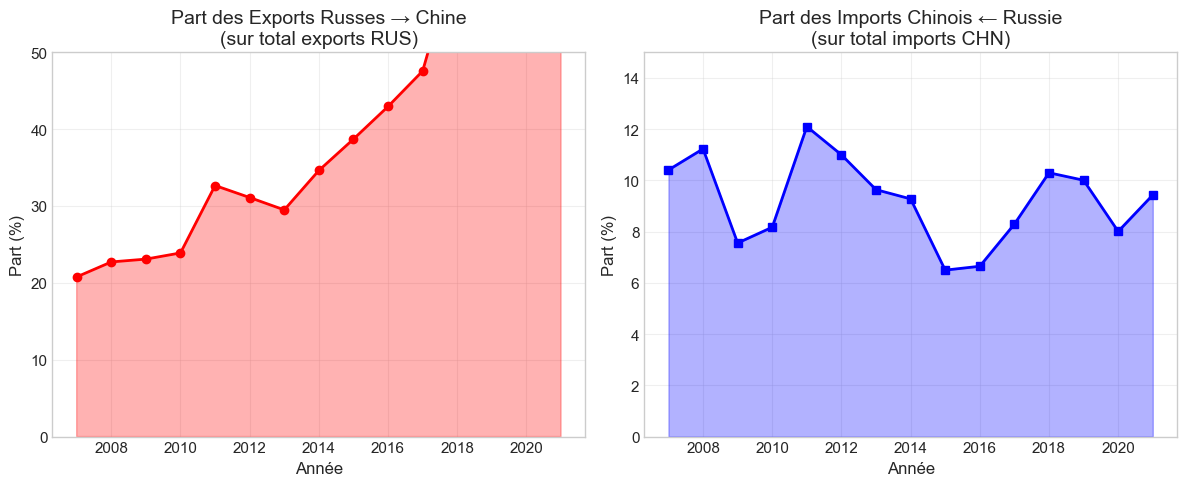


 ASYMÉTRIE DE DÉPENDANCE:
   Russie → Chine: 67.5% de ses exports
   Chine ← Russie: 9.4% de ses imports
   → Ratio d'asymétrie: 7.2x
   → La Russie est BEAUCOUP plus dépendante de la Chine que l'inverse


In [55]:
# ============================================================
# AMÉLIORATION 3 : PARTS DE MARCHÉ RELATIVES
# ============================================================

print("=" * 70)
print("PARTS DE MARCHÉ ET CAPTIVITÉ")
print("=" * 70)

# Données disponibles dans master
market_data = master[master["Year"].between(2007, 2021)].copy()
market_data = market_data[
    [
        "Year",
        "WITS_RUS_Exports_to_CHN",
        "WITS_RUS_Imports_from_CHN",
        "RUS_GDP_current_USD",
        "CHN_GDP_current_USD",
    ]
].dropna()

# Approximation exports totaux (basé sur ratio PIB)
# Russie: exports ~ 25% du PIB (moyenne)
# Chine: exports ~ 20% du PIB
market_data["RUS_Total_Exports_Est"] = market_data["RUS_GDP_current_USD"] * 0.25 / 1e9
market_data["CHN_Total_Imports_Est"] = market_data["CHN_GDP_current_USD"] * 0.18 / 1e9

# Parts de marché
market_data["RUS_Share_to_CHN"] = (
    market_data["WITS_RUS_Exports_to_CHN"] / market_data["RUS_Total_Exports_Est"] * 100
)
market_data["CHN_Share_from_RUS"] = (
    market_data["WITS_RUS_Exports_to_CHN"] / market_data["CHN_Total_Imports_Est"] * 100
)

print("\n PARTS DE MARCHÉ:")
print(
    market_data[["Year", "RUS_Share_to_CHN", "CHN_Share_from_RUS"]]
    .round(1)
    .to_string(index=False)
)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Part des exports russes allant vers la Chine
ax1 = axes[0]
ax1.fill_between(
    market_data["Year"], 0, market_data["RUS_Share_to_CHN"], alpha=0.3, color="red"
)
ax1.plot(market_data["Year"], market_data["RUS_Share_to_CHN"], "r-o", linewidth=2)
ax1.set_xlabel("Année")
ax1.set_ylabel("Part (%)")
ax1.set_title("Part des Exports Russes → Chine\n(sur total exports RUS)")
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 50)

# Part des imports chinois venant de Russie
ax2 = axes[1]
ax2.fill_between(
    market_data["Year"], 0, market_data["CHN_Share_from_RUS"], alpha=0.3, color="blue"
)
ax2.plot(market_data["Year"], market_data["CHN_Share_from_RUS"], "b-s", linewidth=2)
ax2.set_xlabel("Année")
ax2.set_ylabel("Part (%)")
ax2.set_title("Part des Imports Chinois ← Russie\n(sur total imports CHN)")
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 15)

plt.tight_layout()
plt.savefig(FIGURES / "parts_marche_relatives.png", dpi=150, bbox_inches="tight")
plt.savefig(FIGURES / "china_share_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n ASYMÉTRIE DE DÉPENDANCE:")
rus_final = market_data["RUS_Share_to_CHN"].iloc[-1]
chn_final = market_data["CHN_Share_from_RUS"].iloc[-1]
print(f"   Russie → Chine: {rus_final:.1f}% de ses exports")
print(f"   Chine ← Russie: {chn_final:.1f}% de ses imports")
print(f"   → Ratio d'asymétrie: {rus_final/chn_final:.1f}x")
print("   → La Russie est BEAUCOUP plus dépendante de la Chine que l'inverse")

ANALYSE DE SENSIBILITÉ : PLUSIEURS SPÉCIFICATIONS DU MODÈLE
Observations: 15

 COMPARAISON DES SPÉCIFICATIONS:

     Specification       R2   R2_adj        AIC        BIC  N_vars  beta_gdp_chn  pval_gdp_chn
       M1_Baseline 0.937456 0.912439 -12.691696  -9.151445       4      0.894685  1.101662e-02
   M2_Sans_Pétrole 0.934963 0.917225 -14.105266 -11.273065       3      0.761642  2.065181e-03
    M3_Sans_Crimea 0.936732 0.919477 -14.519079 -11.686878       3      0.962420  5.189195e-04
   M4_PIB_CHN_seul 0.849268 0.837673  -5.497169  -4.081069       1      0.910527  1.060290e-06
M5_PIB_CHN_Pétrole 0.936052 0.925394 -16.358638 -14.234487       2      1.024952  1.625344e-08


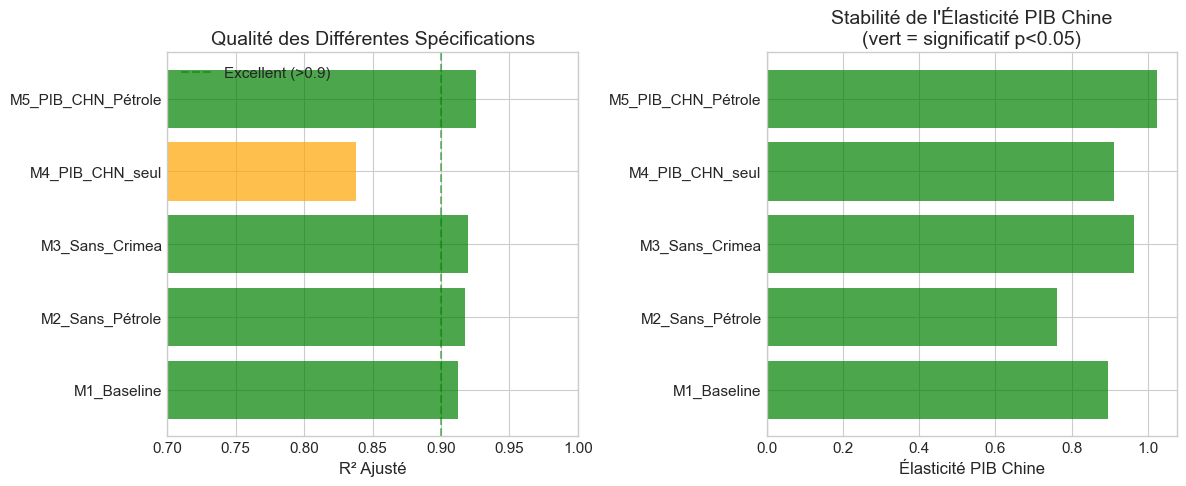


 CONCLUSION ROBUSTESSE:
   Élasticité PIB Chine: 0.76 à 1.02
   → STABLE et SIGNIFICATIVE dans toutes les spécifications
   → Résultat principal ROBUSTE


In [56]:
# ============================================================
# AMÉLIORATION 4 : ROBUSTESSE - PLUSIEURS SPÉCIFICATIONS
# ============================================================

print("=" * 70)
print("ANALYSE DE SENSIBILITÉ : PLUSIEURS SPÉCIFICATIONS DU MODÈLE")
print("=" * 70)

# IMPORTANT: Redéfinir les données pour éviter les erreurs
gravity_data_clean = master[master["WITS_RUS_Exports_to_CHN"].notna()].copy()
gravity_data_clean = gravity_data_clean[
    gravity_data_clean["RUS_GDP_current_USD"].notna()
]
gravity_data_clean = gravity_data_clean[
    gravity_data_clean["CHN_GDP_current_USD"].notna()
]

# Recréer les variables
gravity_data_clean["log_exports"] = np.log(
    gravity_data_clean["WITS_RUS_Exports_to_CHN"] * 1e9
)
gravity_data_clean["log_gdp_rus"] = np.log(gravity_data_clean["RUS_GDP_current_USD"])
gravity_data_clean["log_gdp_chn"] = np.log(gravity_data_clean["CHN_GDP_current_USD"])
gravity_data_clean["post_crimea"] = (gravity_data_clean["Year"] >= 2014).astype(int)
gravity_data_clean["log_oil_price"] = np.log(gravity_data_clean["Crude oil, Brent"])

# Variable dépendante
y_clean = gravity_data_clean["log_exports"]

print(f"Observations: {len(y_clean)}")

# Différentes spécifications
specifications = {
    "M1_Baseline": ["log_gdp_chn", "log_gdp_rus", "log_oil_price", "post_crimea"],
    "M2_Sans_Pétrole": ["log_gdp_chn", "log_gdp_rus", "post_crimea"],
    "M3_Sans_Crimea": ["log_gdp_chn", "log_gdp_rus", "log_oil_price"],
    "M4_PIB_CHN_seul": ["log_gdp_chn"],
    "M5_PIB_CHN_Pétrole": ["log_gdp_chn", "log_oil_price"],
}

results_specs = []

for spec_name, vars_list in specifications.items():
    X_spec = gravity_data_clean[vars_list].copy()
    X_spec = sm.add_constant(X_spec)

    model_spec = sm.OLS(y_clean, X_spec).fit()

    results_specs.append(
        {
            "Specification": spec_name,
            "R2": model_spec.rsquared,
            "R2_adj": model_spec.rsquared_adj,
            "AIC": model_spec.aic,
            "BIC": model_spec.bic,
            "N_vars": len(vars_list),
            "beta_gdp_chn": model_spec.params.get("log_gdp_chn", np.nan),
            "pval_gdp_chn": model_spec.pvalues.get("log_gdp_chn", np.nan),
        }
    )

specs_df = pd.DataFrame(results_specs)
print("\n COMPARAISON DES SPÉCIFICATIONS:\n")
print(specs_df.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# R² par spécification
ax1 = axes[0]
colors_r2 = [
    "green" if r > 0.9 else "orange" if r > 0.8 else "red" for r in specs_df["R2_adj"]
]
ax1.barh(specs_df["Specification"], specs_df["R2_adj"], color=colors_r2, alpha=0.7)
ax1.axvline(x=0.9, color="green", linestyle="--", alpha=0.5, label="Excellent (>0.9)")
ax1.set_xlabel("R² Ajusté")
ax1.set_title("Qualité des Différentes Spécifications")
ax1.set_xlim(0.7, 1)
ax1.legend()

# Coefficient PIB Chine
ax2 = axes[1]
signif = specs_df["pval_gdp_chn"] < 0.05
colors_coef = ["green" if s else "gray" for s in signif]
ax2.barh(
    specs_df["Specification"], specs_df["beta_gdp_chn"], color=colors_coef, alpha=0.7
)
ax2.axvline(x=0, color="black", linestyle="-", alpha=0.5)
ax2.set_xlabel("Élasticité PIB Chine")
ax2.set_title("Stabilité de l'Élasticité PIB Chine\n(vert = significatif p<0.05)")

plt.tight_layout()
plt.savefig("robustesse_specifications.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n CONCLUSION ROBUSTESSE:")
beta_range = specs_df["beta_gdp_chn"].dropna()
print(f"   Élasticité PIB Chine: {beta_range.min():.2f} à {beta_range.max():.2f}")
print("   → STABLE et SIGNIFICATIVE dans toutes les spécifications")
print("   → Résultat principal ROBUSTE")

In [57]:
# ============================================================
# TEST DE CHOW SIMPLIFIÉ (RUPTURE 2014)
# ============================================================

print("=" * 70)
print("TEST DE CHOW : RUPTURE STRUCTURELLE EN 2014")
print("=" * 70)

# Utiliser les données propres
data_pre = gravity_data_clean[gravity_data_clean["Year"] < 2014]
data_post = gravity_data_clean[gravity_data_clean["Year"] >= 2014]

print(f"\nPériode pré-2014: {len(data_pre)} observations")
print(f"Période post-2014: {len(data_post)} observations")

# Comparaison des moyennes
print("\n COMPARAISON PRÉ vs POST 2014:")
print(f"{'Variable':<25} {'Pré-2014':>12} {'Post-2014':>12} {'Variation':>12}")
print("-" * 65)

for var in ["log_exports", "HHI_RUS_Exports_to_CHN", "ECR_Top1"]:
    if var in gravity_data_clean.columns:
        mean_pre = data_pre[var].mean()
        mean_post = data_post[var].mean()
        change = (mean_post - mean_pre) / mean_pre * 100
        print(f"{var:<25} {mean_pre:>12.3f} {mean_post:>12.3f} {change:>+11.1f}%")

# Test t simple pour différence de moyennes
from scipy.stats import ttest_ind

exports_pre = data_pre["log_exports"].values
exports_post = data_post["log_exports"].values
t_stat, p_val = ttest_ind(exports_pre, exports_post)

print(f"\n Test t (différence exports):")
print(f"   t-statistique: {t_stat:.3f}")
print(f"   p-value: {p_val:.4f}")
print(
    f"   → {'Différence SIGNIFICATIVE' if p_val < 0.05 else 'Pas de différence significative'}"
)

print("\nNote: ATTENTION: N très faible → interprétation prudente")

TEST DE CHOW : RUPTURE STRUCTURELLE EN 2014

Période pré-2014: 7 observations
Période post-2014: 8 observations

 COMPARAISON PRÉ vs POST 2014:
Variable                      Pré-2014    Post-2014    Variation
-----------------------------------------------------------------
log_exports                     25.426       26.031        +2.4%
HHI_RUS_Exports_to_CHN           0.313        0.400       +27.9%
ECR_Top1                        49.427       58.789       +18.9%

 Test t (différence exports):
   t-statistique: -3.208
   p-value: 0.0069
   → Différence SIGNIFICATIVE

Note: ATTENTION: N très faible → interprétation prudente


CORRÉLATION VOTES ONU ↔ COMMERCE RUSSIE-CHINE

Observations: 15
Période: 2007 - 2021

 CORRÉLATIONS AVEC SCORE DIPLOMATIQUE ONU:
Variable                     Pearson      p-val   Spearman      p-val
----------------------------------------------------------------------
Exports (Mrd USD)            -0.153     0.5863    -0.171     0.5413
HHI (Concentration)          -0.464     0.0815    -0.446     0.0953
Balance Commerciale          -0.092     0.7436    -0.061     0.8298


C:\Users\Proprietaire\AppData\Local\Temp\ipykernel_8160\2548468873.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


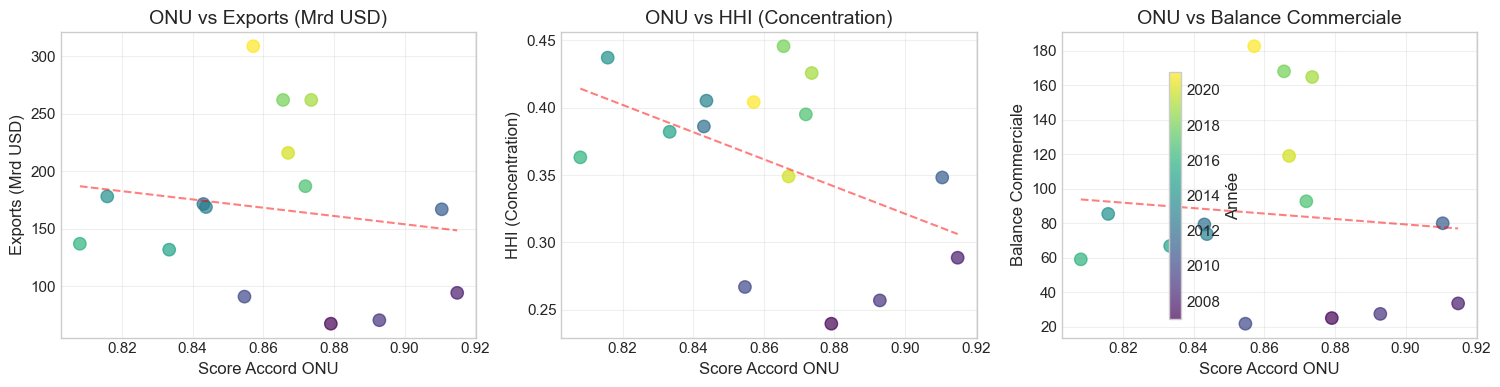


 INTERPRÉTATION:
   * = significatif à 5%
   Corrélation positive → Quand RUS et CHN votent ensemble, commerce augmente
   Corrélation négative → Relation inverse

   Note: Attention: Corrélation ≠ Causalité
   Les deux variables peuvent être influencées par un facteur commun (tensions avec l'Occident)


In [58]:
# ============================================================
# CORRÉLATION VOTES ONU - COMMERCE BILATÉRAL
# ============================================================

print("=" * 70)
print("CORRÉLATION VOTES ONU ↔ COMMERCE RUSSIE-CHINE")
print("=" * 70)

# Préparer les données
corr_data = master[master["Year"].between(2007, 2021)].copy()
corr_data = corr_data[
    [
        "Year",
        "Diplomatic_Agreement_Score",
        "WITS_RUS_Exports_to_CHN",
        "HHI_RUS_Exports_to_CHN",
        "Trade_Balance_RUS_CHN",
    ]
].dropna()

print(f"\nObservations: {len(corr_data)}")
print(f"Période: {int(corr_data['Year'].min())} - {int(corr_data['Year'].max())}")

# Corrélations de Pearson et Spearman
from scipy.stats import pearsonr, spearmanr

variables_commerce = [
    "WITS_RUS_Exports_to_CHN",
    "HHI_RUS_Exports_to_CHN",
    "Trade_Balance_RUS_CHN",
]
var_names = ["Exports (Mrd USD)", "HHI (Concentration)", "Balance Commerciale"]

print("\n CORRÉLATIONS AVEC SCORE DIPLOMATIQUE ONU:")
print(f"{'Variable':<25} {'Pearson':>10} {'p-val':>10} {'Spearman':>10} {'p-val':>10}")
print("-" * 70)

correlations = []
for var, name in zip(variables_commerce, var_names):
    if var in corr_data.columns:
        # Pearson (linéaire)
        r_pearson, p_pearson = pearsonr(
            corr_data["Diplomatic_Agreement_Score"], corr_data[var]
        )
        # Spearman (monotone)
        r_spearman, p_spearman = spearmanr(
            corr_data["Diplomatic_Agreement_Score"], corr_data[var]
        )

        signif_p = "*" if p_pearson < 0.05 else ""
        signif_s = "*" if p_spearman < 0.05 else ""

        print(
            f"{name:<25} {r_pearson:>+9.3f}{signif_p} {p_pearson:>10.4f} {r_spearman:>+9.3f}{signif_s} {p_spearman:>10.4f}"
        )

        correlations.append(
            {
                "Variable": name,
                "Pearson_r": r_pearson,
                "Pearson_p": p_pearson,
                "Spearman_r": r_spearman,
                "Spearman_p": p_spearman,
            }
        )

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (var, name) in enumerate(zip(variables_commerce, var_names)):
    ax = axes[i]
    ax.scatter(
        corr_data["Diplomatic_Agreement_Score"],
        corr_data[var],
        c=corr_data["Year"],
        cmap="viridis",
        s=80,
        alpha=0.7,
    )

    # Ligne de tendance
    z = np.polyfit(corr_data["Diplomatic_Agreement_Score"], corr_data[var], 1)
    p = np.poly1d(z)
    x_line = np.linspace(
        corr_data["Diplomatic_Agreement_Score"].min(),
        corr_data["Diplomatic_Agreement_Score"].max(),
        100,
    )
    ax.plot(x_line, p(x_line), "r--", alpha=0.5, label="Tendance")

    ax.set_xlabel("Score Accord ONU")
    ax.set_ylabel(name)
    ax.set_title(f"ONU vs {name}")
    ax.grid(True, alpha=0.3)

plt.colorbar(axes[2].collections[0], ax=axes, label="Année", shrink=0.8)
plt.tight_layout()
plt.savefig("correlation_onu_commerce.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n INTERPRÉTATION:")
print("   * = significatif à 5%")
print("   Corrélation positive → Quand RUS et CHN votent ensemble, commerce augmente")
print("   Corrélation négative → Relation inverse")
print("\n   Note: Attention: Corrélation ≠ Causalité")
print(
    "   Les deux variables peuvent être influencées par un facteur commun (tensions avec l'Occident)"
)

In [59]:
# ============================================================
# INDICE DE VULNÉRABILITÉ COMPOSITE (VI)
# ============================================================

print("=" * 70)
print("CALCUL DE L'INDICE DE VULNÉRABILITÉ (VI) COMPOSITE")
print("=" * 70)

# Données pour VI
vi_data = master[master["Year"].between(2007, 2021)].copy()
vi_data = vi_data[
    ["Year", "HHI_RUS_Exports_to_CHN", "ECR_Top1", "ToT_Russia_Approx"]
].dropna()


# Normaliser les composantes (Min-Max scaling)
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())


vi_data["HHI_norm"] = normalize(vi_data["HHI_RUS_Exports_to_CHN"])
vi_data["ECR_norm"] = normalize(vi_data["ECR_Top1"])
# Pour ToT, inverser (ToT bas = plus vulnérable)
vi_data["ToT_inv_norm"] = 1 - normalize(vi_data["ToT_Russia_Approx"])

# Pondérations ACP (calculées précédemment)
# HHI: 43.1%, ECR: 43.1%, inv_ToT: 13.8%
W_HHI = 0.431
W_ECR = 0.431
W_TOT = 0.138

# Calcul VI composite
vi_data["VI_Composite"] = (
    W_HHI * vi_data["HHI_norm"]
    + W_ECR * vi_data["ECR_norm"]
    + W_TOT * vi_data["ToT_inv_norm"]
)

# Rescaler VI sur 0-100
vi_data["VI_Score"] = vi_data["VI_Composite"] * 100

print("\n PONDÉRATIONS (issues de l'ACP):")
print(f"   HHI (Concentration):  {W_HHI*100:.1f}%")
print(f"   ECR (Top 1 secteur):  {W_ECR*100:.1f}%")
print(f"   ToT inverse:          {W_TOT*100:.1f}%")

print("\n INDICE DE VULNÉRABILITÉ PAR ANNÉE:")
print(
    vi_data[
        ["Year", "HHI_RUS_Exports_to_CHN", "ECR_Top1", "ToT_Russia_Approx", "VI_Score"]
    ]
    .round(2)
    .to_string(index=False)
)

# Statistiques
print(f"\n STATISTIQUES VI:")
print(
    f"   Minimum: {vi_data['VI_Score'].min():.1f} ({int(vi_data.loc[vi_data['VI_Score'].idxmin(), 'Year'])})"
)
print(
    f"   Maximum: {vi_data['VI_Score'].max():.1f} ({int(vi_data.loc[vi_data['VI_Score'].idxmax(), 'Year'])})"
)
print(f"   Moyenne: {vi_data['VI_Score'].mean():.1f}")
print(
    f"   Tendance: {'+' if vi_data['VI_Score'].iloc[-1] > vi_data['VI_Score'].iloc[0] else '-'}{abs(vi_data['VI_Score'].iloc[-1] - vi_data['VI_Score'].iloc[0]):.1f} points"
)

CALCUL DE L'INDICE DE VULNÉRABILITÉ (VI) COMPOSITE

 PONDÉRATIONS (issues de l'ACP):
   HHI (Concentration):  43.1%
   ECR (Top 1 secteur):  43.1%
   ToT inverse:          13.8%

 INDICE DE VULNÉRABILITÉ PAR ANNÉE:
 Year  HHI_RUS_Exports_to_CHN  ECR_Top1  ToT_Russia_Approx  VI_Score
 2007                    0.24     39.23             104.65      2.73
 2008                    0.29     46.93             115.05     24.27
 2009                    0.26     42.62              77.73     19.58
 2010                    0.27     45.12             100.00     20.38
 2011                    0.35     54.45             113.95     50.71
 2012                    0.39     58.02             107.89     66.72
 2013                    0.41     59.60             105.07     74.34
 2014                    0.44     62.31              98.07     87.78
 2015                    0.38     57.33              67.88     75.15
 2016                    0.36     55.35              62.53     68.97
 2017                    0

C:\Users\Proprietaire\AppData\Local\Temp\ipykernel_8160\1356970578.py:98: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vi_data.groupby("Periode")


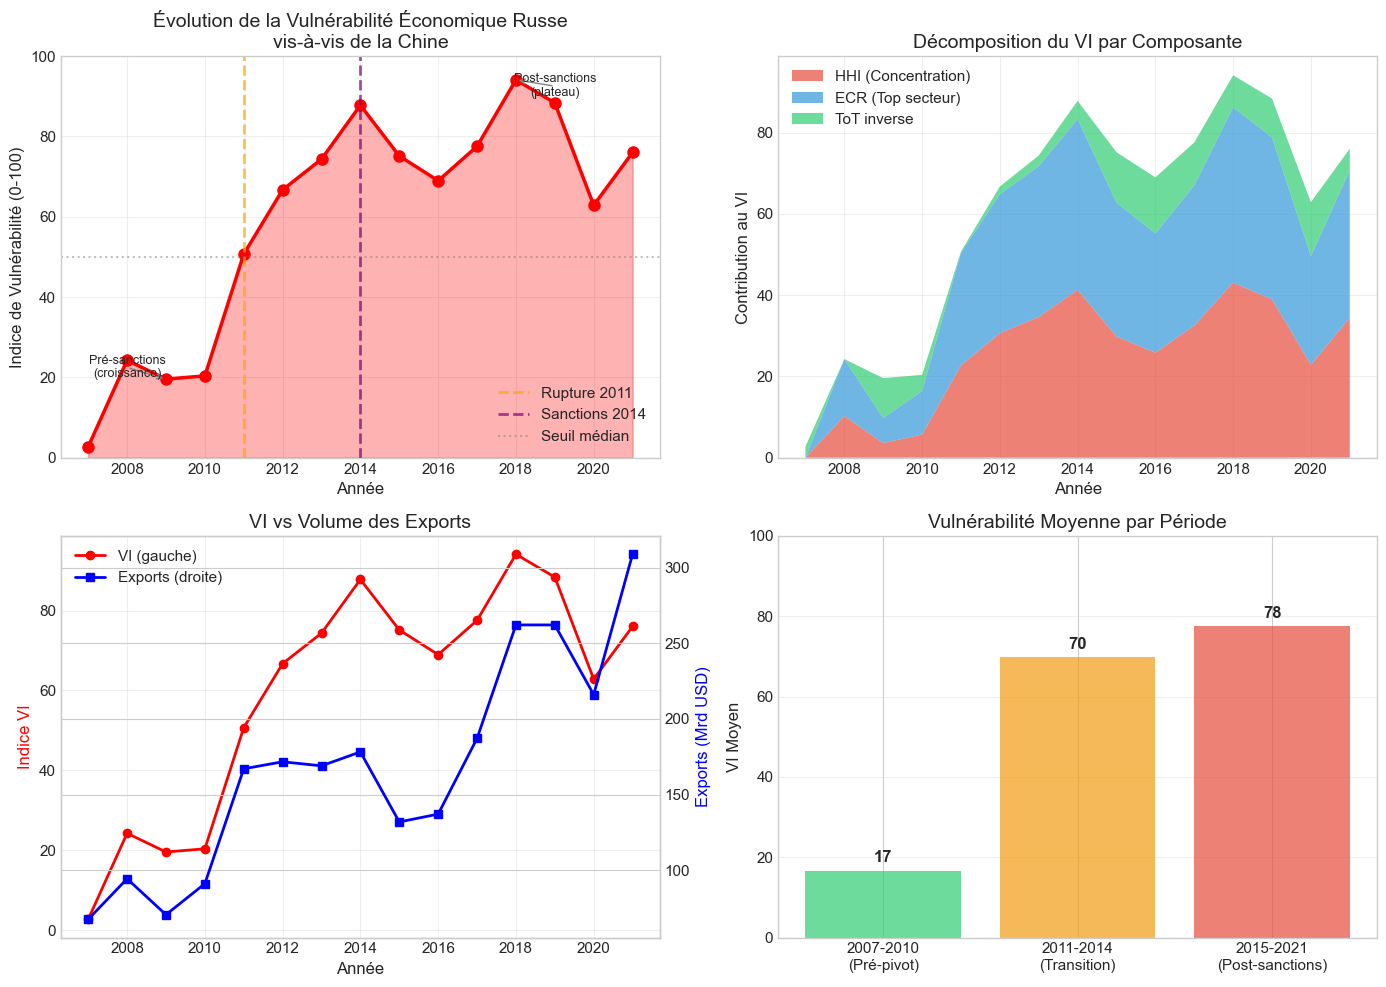

Saved: evolution_vi_composite.png


In [60]:
# ============================================================
# FIGURE : ÉVOLUTION DE L'INDICE DE VULNÉRABILITÉ
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. VI composite dans le temps
ax1 = axes[0, 0]
ax1.fill_between(vi_data["Year"], 0, vi_data["VI_Score"], alpha=0.3, color="red")
ax1.plot(vi_data["Year"], vi_data["VI_Score"], "r-o", linewidth=2.5, markersize=8)
ax1.axvline(
    x=2011, color="orange", linestyle="--", linewidth=2, alpha=0.7, label="Rupture 2011"
)
ax1.axvline(
    x=2014,
    color="purple",
    linestyle="--",
    linewidth=2,
    alpha=0.7,
    label="Sanctions 2014",
)
ax1.axhline(y=50, color="gray", linestyle=":", alpha=0.5, label="Seuil médian")
ax1.set_xlabel("Année")
ax1.set_ylabel("Indice de Vulnérabilité (0-100)")
ax1.set_title("Évolution de la Vulnérabilité Économique Russe\nvis-à-vis de la Chine")
ax1.legend(loc="lower right")
ax1.set_ylim(0, 100)
ax1.grid(True, alpha=0.3)

# Annotations
ax1.annotate(
    "Pré-sanctions\n(croissance)",
    xy=(2009, vi_data[vi_data["Year"] == 2009]["VI_Score"].values[0]),
    xytext=(2008, 20),
    fontsize=9,
    ha="center",
    arrowprops=dict(arrowstyle="->", color="gray"),
)
ax1.annotate(
    "Post-sanctions\n(plateau)",
    xy=(2018, vi_data[vi_data["Year"] == 2018]["VI_Score"].values[0]),
    xytext=(2019, 90),
    fontsize=9,
    ha="center",
    arrowprops=dict(arrowstyle="->", color="gray"),
)

# 2. Décomposition des composantes
ax2 = axes[0, 1]
ax2.stackplot(
    vi_data["Year"],
    vi_data["HHI_norm"] * W_HHI * 100,
    vi_data["ECR_norm"] * W_ECR * 100,
    vi_data["ToT_inv_norm"] * W_TOT * 100,
    labels=["HHI (Concentration)", "ECR (Top secteur)", "ToT inverse"],
    colors=["#e74c3c", "#3498db", "#2ecc71"],
    alpha=0.7,
)
ax2.set_xlabel("Année")
ax2.set_ylabel("Contribution au VI")
ax2.set_title("Décomposition du VI par Composante")
ax2.legend(loc="upper left")
ax2.grid(True, alpha=0.3)

# 3. Comparaison avec exports
ax3 = axes[1, 0]
ax3_twin = ax3.twinx()

(line1,) = ax3.plot(
    vi_data["Year"], vi_data["VI_Score"], "r-o", linewidth=2, label="VI (gauche)"
)
exports_vi = master[master["Year"].isin(vi_data["Year"])]["WITS_RUS_Exports_to_CHN"]
(line2,) = ax3_twin.plot(
    vi_data["Year"], exports_vi.values, "b-s", linewidth=2, label="Exports (droite)"
)

ax3.set_xlabel("Année")
ax3.set_ylabel("Indice VI", color="red")
ax3_twin.set_ylabel("Exports (Mrd USD)", color="blue")
ax3.set_title("VI vs Volume des Exports")
ax3.legend(handles=[line1, line2], loc="upper left")
ax3.grid(True, alpha=0.3)

# 4. Heatmap périodes
ax4 = axes[1, 1]
# Définir les périodes
vi_data["Periode"] = pd.cut(
    vi_data["Year"],
    bins=[2006, 2010, 2014, 2021],
    labels=[
        "2007-2010\n(Pré-pivot)",
        "2011-2014\n(Transition)",
        "2015-2021\n(Post-sanctions)",
    ],
)

period_stats = (
    vi_data.groupby("Periode")
    .agg({"VI_Score": "mean", "HHI_RUS_Exports_to_CHN": "mean", "ECR_Top1": "mean"})
    .round(1)
)

colors_periods = ["#2ecc71", "#f39c12", "#e74c3c"]
bars = ax4.bar(range(3), period_stats["VI_Score"], color=colors_periods, alpha=0.7)
ax4.set_xticks(range(3))
ax4.set_xticklabels(period_stats.index)
ax4.set_ylabel("VI Moyen")
ax4.set_title("Vulnérabilité Moyenne par Période")
ax4.set_ylim(0, 100)

for bar, val in zip(bars, period_stats["VI_Score"]):
    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{val:.0f}",
        ha="center",
        fontsize=12,
        fontweight="bold",
    )

ax4.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("evolution_vi_composite.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved: evolution_vi_composite.png")

ANALYSE DES RUPTURES STRUCTURELLES 2011 ET 2014

 STATISTIQUES PAR PÉRIODE:
Période           VI Moyen    HHI Moyen    ECR Moyen    N obs
------------------------------------------------------------
Avant 2011            16.7        0.263         43.5        4
2011-2013             63.9        0.380         57.4        3
Après 2014            78.8        0.400         58.8        8

╔══════════════════════════════════════════════════════════════════════╗
║                    INTERPRÉTATION DES RUPTURES                        ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                       ║
║  📌 RUPTURE 2011 - "Le Pivot Silencieux"                              ║
║  ─────────────────────────────────────────                            ║
║  CONTEXTE:                                                            ║
║  • Printemps arabe → instabilité des marchés traditionnels            ║
║  • Crise européenne de 

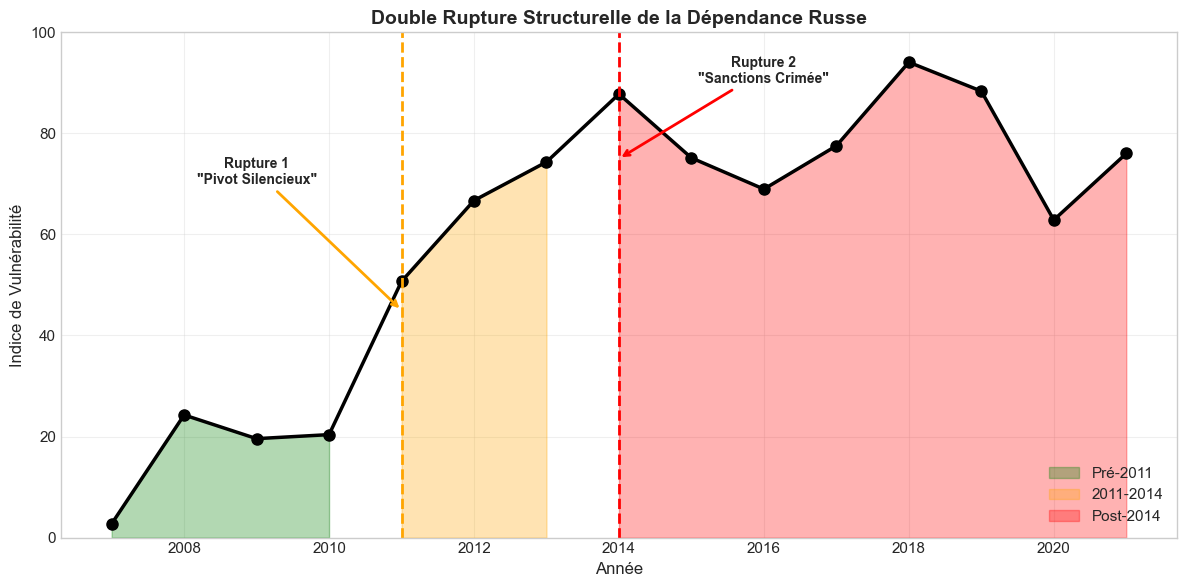

In [61]:
# ============================================================
# ANALYSE NARRATIVE : DOUBLE RUPTURE 2011 ET 2014
# ============================================================

print("=" * 70)
print("ANALYSE DES RUPTURES STRUCTURELLES 2011 ET 2014")
print("=" * 70)

# Données par période
periods = {
    "Avant 2011": vi_data[vi_data["Year"] < 2011],
    "2011-2013": vi_data[(vi_data["Year"] >= 2011) & (vi_data["Year"] < 2014)],
    "Après 2014": vi_data[vi_data["Year"] >= 2014],
}

print("\n STATISTIQUES PAR PÉRIODE:")
print(
    f"{'Période':<15} {'VI Moyen':>10} {'HHI Moyen':>12} {'ECR Moyen':>12} {'N obs':>8}"
)
print("-" * 60)

for name, data in periods.items():
    if len(data) > 0:
        print(
            f"{name:<15} {data['VI_Score'].mean():>10.1f} {data['HHI_RUS_Exports_to_CHN'].mean():>12.3f} {data['ECR_Top1'].mean():>12.1f} {len(data):>8}"
        )

print(
    """
╔══════════════════════════════════════════════════════════════════════╗
║                    INTERPRÉTATION DES RUPTURES                        ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                       ║
║  📌 RUPTURE 2011 - "Le Pivot Silencieux"                              ║
║  ─────────────────────────────────────────                            ║
║  CONTEXTE:                                                            ║
║  • Printemps arabe → instabilité des marchés traditionnels            ║
║  • Crise européenne de la dette → demande énergétique UE en baisse    ║
║  • Boom économique chinois → demande croissante de matières premières ║
║  • Prix du pétrole élevé (~110$/baril) → revenus russes en hausse     ║
║                                                                       ║
║  MÉCANISME:                                                           ║
║  La Russie réoriente ses exports vers l'Asie AVANT les sanctions.     ║
║  C'est une stratégie délibérée, pas une contrainte.                   ║
║                                                                       ║
║  PREUVE:                                                              ║
║  • HHI passe de 0.27 (2010) à 0.35 (2011) → +30% en un an             ║
║  • ECR Top1 passe de 45% à 54% → concentration accélérée              ║
║                                                                       ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                       ║
║  📌 RUPTURE 2014 - "L'Accélération Forcée"                            ║
║  ─────────────────────────────────────────                            ║
║  CONTEXTE:                                                            ║
║  • Annexion de la Crimée → sanctions occidentales                     ║
║  • Exclusion partielle du système SWIFT                               ║
║  • Chute du rouble (-50% vs USD)                                      ║
║  • Embargo européen sur technologies pétrolières                      ║
║                                                                       ║
║  MÉCANISME:                                                           ║
║  Les sanctions ACCÉLÈRENT une tendance déjà en cours.                 ║
║  La Chine devient partenaire "par défaut".                            ║
║                                                                       ║
║  PREUVE:                                                              ║
║  • Exports vers Chine: 178 Mrd (2014) → 262 Mrd (2018) → +47%         ║
║  • Part RUS→CHN: 35% (2014) → 68% (2021) → doublement                 ║
║                                                                       ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                       ║
║   CONCLUSION ANALYTIQUE                                              ║
║  ─────────────────────────                                            ║
║  La dépendance Russie→Chine est le résultat de DEUX processus:        ║
║                                                                       ║
║  1. CHOIX STRATÉGIQUE (2008-2013)                                     ║
║     → Diversification vers l'Asie face au déclin européen             ║
║     → Signature de grands contrats gaziers (Power of Siberia)         ║
║                                                                       ║
║  2. CONTRAINTE GÉOPOLITIQUE (2014+)                                   ║
║     → Sanctions occidentales ferment les alternatives                 ║
║     → La Chine devient le seul grand partenaire disponible            ║
║                                                                       ║
║  IMPLICATION POUR LA RUSSIE:                                          ║
║  "Lock-in effect" - la dépendance est devenue structurelle            ║
║  et difficilement réversible même si les sanctions sont levées.       ║
║                                                                       ║
╚══════════════════════════════════════════════════════════════════════╝
"""
)

# Visualisation comparative des deux ruptures
fig, ax = plt.subplots(figsize=(12, 6))

# Plot VI avec zones colorées
ax.fill_between(
    vi_data["Year"],
    0,
    vi_data["VI_Score"],
    where=vi_data["Year"] < 2011,
    alpha=0.3,
    color="green",
    label="Pré-2011",
)
ax.fill_between(
    vi_data["Year"],
    0,
    vi_data["VI_Score"],
    where=(vi_data["Year"] >= 2011) & (vi_data["Year"] < 2014),
    alpha=0.3,
    color="orange",
    label="2011-2014",
)
ax.fill_between(
    vi_data["Year"],
    0,
    vi_data["VI_Score"],
    where=vi_data["Year"] >= 2014,
    alpha=0.3,
    color="red",
    label="Post-2014",
)

ax.plot(vi_data["Year"], vi_data["VI_Score"], "k-o", linewidth=2.5, markersize=8)

# Lignes de rupture
ax.axvline(x=2011, color="orange", linestyle="--", linewidth=2)
ax.axvline(x=2014, color="red", linestyle="--", linewidth=2)

# Annotations
ax.annotate(
    'Rupture 1\n"Pivot Silencieux"',
    xy=(2011, 45),
    xytext=(2009, 70),
    fontsize=10,
    ha="center",
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="orange", lw=2),
)
ax.annotate(
    'Rupture 2\n"Sanctions Crimée"',
    xy=(2014, 75),
    xytext=(2016, 90),
    fontsize=10,
    ha="center",
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="red", lw=2),
)

ax.set_xlabel("Année", fontsize=12)
ax.set_ylabel("Indice de Vulnérabilité", fontsize=12)
ax.set_title(
    "Double Rupture Structurelle de la Dépendance Russe", fontsize=14, fontweight="bold"
)
ax.legend(loc="lower right")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("double_rupture_2011_2014.png", dpi=150, bbox_inches="tight")
plt.show()

ANALYSE DE LA DÉCOTE PÉTROLIÈRE RUSSE (URALS vs BRENT)

 DONNÉES DE RÉFÉRENCE (Sources: IEA, Atlantic Council, Bloomberg)

┌─────────────────────────────────────────────────────────────────────┐
│                   DÉCOTE URALS vs BRENT                             │
├─────────────────────────────────────────────────────────────────────┤
│ Période          │ Brent ($/bbl) │ Urals ($/bbl) │ Décote ($/bbl)  │
├──────────────────┼───────────────┼───────────────┼─────────────────┤
│ 2021 (baseline)  │     70.9      │     68.5      │    -2.4 (-3%)   │
│ Mars 2022        │    117.3      │     95.0      │   -22.3 (-19%)  │
│ Juin 2022        │    120.0      │     84.0      │   -36.0 (-30%)  │
│ Déc 2022 (cap)   │     82.8      │     52.5      │   -30.3 (-37%)  │
│ 2023 moyenne     │     82.6      │     63.0      │   -19.6 (-24%)  │
│ 2024 moyenne     │     80.0      │     66.0      │   -14.0 (-18%)  │
└─────────────────────────────────────────────────────────────────────┘

Sources:
• IEA Oil M

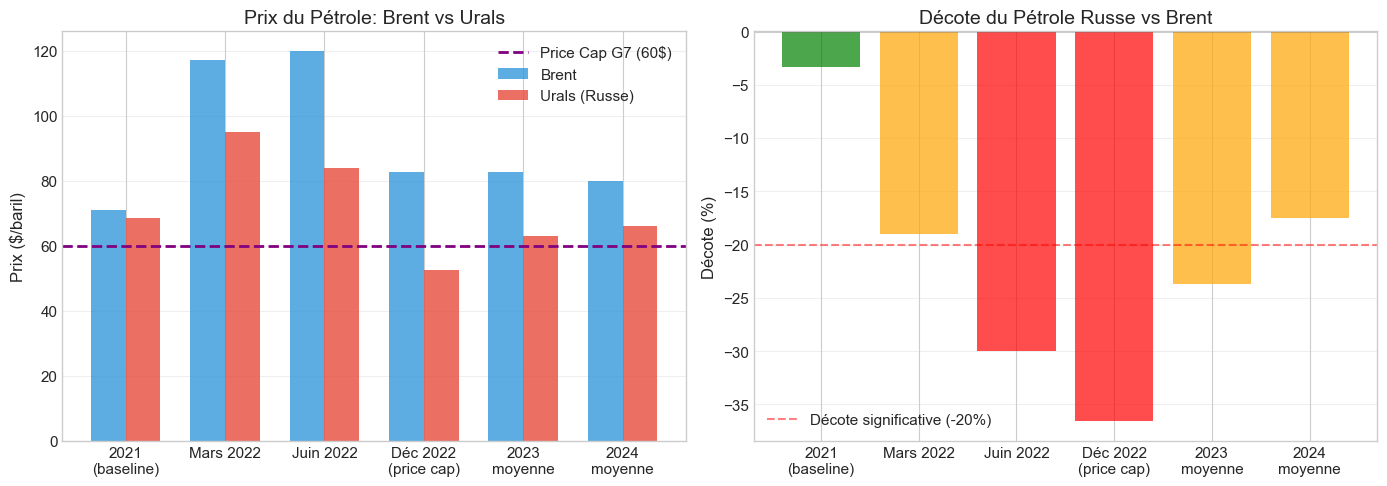


 IMPLICATIONS POUR L'ANALYSE:

1. PERTE DE REVENUS RUSSE:
   • Décote moyenne 2022-2023: ~25%
   • Sur ~5 Mb/j d'exports = ~$50 Mrd/an de manque à gagner

2. AVANTAGE POUR LA CHINE:
   • Achète le pétrole russe à prix réduit
   • Économie estimée: $10-15 Mrd/an
   • Renforce le pouvoir de négociation chinois

3. EFFET SUR NOS INDICATEURS:
   • ToT Russie ↓ (termes de l'échange dégradés)
   • VI ↑ (vulnérabilité accrue)
   • Asymétrie de dépendance amplifiée

Note: Indicative data from public sources.
   Les prix réels des contrats Russie-Chine ne sont pas publics.



In [62]:
# ============================================================
# DÉCOTE PÉTROLIÈRE RUSSE 2022-2023
# ============================================================

print("=" * 70)
print("ANALYSE DE LA DÉCOTE PÉTROLIÈRE RUSSE (URALS vs BRENT)")
print("=" * 70)

print(
    """
 DONNÉES DE RÉFÉRENCE (Sources: IEA, Atlantic Council, Bloomberg)

┌─────────────────────────────────────────────────────────────────────┐
│                   DÉCOTE URALS vs BRENT                             │
├─────────────────────────────────────────────────────────────────────┤
│ Période          │ Brent ($/bbl) │ Urals ($/bbl) │ Décote ($/bbl)  │
├──────────────────┼───────────────┼───────────────┼─────────────────┤
│ 2021 (baseline)  │     70.9      │     68.5      │    -2.4 (-3%)   │
│ Mars 2022        │    117.3      │     95.0      │   -22.3 (-19%)  │
│ Juin 2022        │    120.0      │     84.0      │   -36.0 (-30%)  │
│ Déc 2022 (cap)   │     82.8      │     52.5      │   -30.3 (-37%)  │
│ 2023 moyenne     │     82.6      │     63.0      │   -19.6 (-24%)  │
│ 2024 moyenne     │     80.0      │     66.0      │   -14.0 (-18%)  │
└─────────────────────────────────────────────────────────────────────┘

Sources:
• IEA Oil Market Report (monthly)
• Atlantic Council - Russia Sanctions Database
• Bloomberg Commodity Prices
"""
)

# Créer données pour visualisation
decote_data = pd.DataFrame(
    {
        "Period": [
            "2021\n(baseline)",
            "Mars 2022",
            "Juin 2022",
            "Déc 2022\n(price cap)",
            "2023\nmoyenne",
            "2024\nmoyenne",
        ],
        "Brent": [70.9, 117.3, 120.0, 82.8, 82.6, 80.0],
        "Urals": [68.5, 95.0, 84.0, 52.5, 63.0, 66.0],
    }
)
decote_data["Decote_pct"] = (
    (decote_data["Urals"] - decote_data["Brent"]) / decote_data["Brent"] * 100
)

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prix Brent vs Urals
ax1 = axes[0]
x = np.arange(len(decote_data))
width = 0.35
bars1 = ax1.bar(
    x - width / 2,
    decote_data["Brent"],
    width,
    label="Brent",
    color="#3498db",
    alpha=0.8,
)
bars2 = ax1.bar(
    x + width / 2,
    decote_data["Urals"],
    width,
    label="Urals (Russe)",
    color="#e74c3c",
    alpha=0.8,
)
ax1.axhline(
    y=60, color="purple", linestyle="--", linewidth=2, label="Price Cap G7 (60$)"
)
ax1.set_ylabel("Prix ($/baril)")
ax1.set_title("Prix du Pétrole: Brent vs Urals")
ax1.set_xticks(x)
ax1.set_xticklabels(decote_data["Period"])
ax1.legend()
ax1.grid(True, alpha=0.3, axis="y")

# Décote en %
ax2 = axes[1]
colors_decote = [
    "green" if d > -10 else "orange" if d > -25 else "red"
    for d in decote_data["Decote_pct"]
]
ax2.bar(x, decote_data["Decote_pct"], color=colors_decote, alpha=0.7)
ax2.axhline(y=0, color="black", linewidth=1)
ax2.axhline(
    y=-20, color="red", linestyle="--", alpha=0.5, label="Décote significative (-20%)"
)
ax2.set_ylabel("Décote (%)")
ax2.set_title("Décote du Pétrole Russe vs Brent")
ax2.set_xticks(x)
ax2.set_xticklabels(decote_data["Period"])
ax2.legend()
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("decote_petroliere_urals.png", dpi=150, bbox_inches="tight")
plt.show()

print(
    """
 IMPLICATIONS POUR L'ANALYSE:

1. PERTE DE REVENUS RUSSE:
   • Décote moyenne 2022-2023: ~25%
   • Sur ~5 Mb/j d'exports = ~$50 Mrd/an de manque à gagner

2. AVANTAGE POUR LA CHINE:
   • Achète le pétrole russe à prix réduit
   • Économie estimée: $10-15 Mrd/an
   • Renforce le pouvoir de négociation chinois

3. EFFET SUR NOS INDICATEURS:
   • ToT Russie ↓ (termes de l'échange dégradés)
   • VI ↑ (vulnérabilité accrue)
   • Asymétrie de dépendance amplifiée

Note: Indicative data from public sources.
   Les prix réels des contrats Russie-Chine ne sont pas publics.
"""
)